In [340]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wyświetlania
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


 1. Struktura danych
 Czy dane zostały poprawnie wczytane (sprawdzenie .head() i .info())?
 Ile jest kolumn i wierszy?
 Jakie są typy danych (int, float, object, datetime)?

In [342]:

# Wczytanie danych z beneficiary
train_provider = pd.read_csv('Train-1542865627584.csv')

# sprawdzenie head
train_provider.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [343]:
# sprawdzenie info
train_provider.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Provider        5410 non-null   object
 1   PotentialFraud  5410 non-null   object
dtypes: object(2)
memory usage: 84.7+ KB


Widać że PotentialFraud ma wartości tylko Yes/No to flaga klasyfikacji ("Yes" / "No"), więc idealnie powinna być bool lub category.

In [345]:
# Konwersja na flagę binarną
train_provider['FraudFlag'] = train_provider['PotentialFraud'].map({'Yes': 1, 'No': 0})

# Sprawdź typy
print(train_provider.dtypes)

Provider          object
PotentialFraud    object
FraudFlag          int64
dtype: object


In [346]:
train_provider['PotentialFraud'] = train_provider['PotentialFraud'].astype('category')
train_provider.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Provider        5410 non-null   object  
 1   PotentialFraud  5410 non-null   category
 2   FraudFlag       5410 non-null   int64   
dtypes: category(1), int64(1), object(1)
memory usage: 90.1+ KB


In [347]:
train_provider.shape

(5410, 3)

In [348]:
rows, cols = train_provider.shape
print(f"Liczba wierszy: {rows}")
print(f"Liczba kolumn: {cols}")

Liczba wierszy: 5410
Liczba kolumn: 3


In [349]:
# Wczytanie danych z beneficiary
train_beneficiary = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')

# sprawdzenie head
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


In [350]:
train_beneficiary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

In [351]:
#DOB i DOD powinny być datetime

In [352]:
train_beneficiary.shape

(138556, 25)

In [353]:
train_beneficiary['RenalDiseaseIndicator'].value_counts()

RenalDiseaseIndicator
0    118978
Y     19578
Name: count, dtype: int64

In [354]:
#renalDiseaseIndicator albo nie mamy danych wtedy 0 albo jest ktoś chory

Ile osób  > 65 ma renalDiseaseIdicator

In [356]:
#Ile osób  > 65 ma renalDiseaseIndicator na true

# Zamiana DOB na datetime
train_beneficiary['DOB'] = pd.to_datetime(train_beneficiary['DOB'], errors='coerce')

# Data odniesienia: koniec 2009 roku
reference_date = pd.to_datetime('2009-12-31')

# Obliczenie wieku
train_beneficiary['Age'] = ((reference_date - train_beneficiary['DOB']).dt.days // 365)

# 🧮 Licznik: osoby > 65 z chorobą nerek
renal_over_65 = train_beneficiary[
    (train_beneficiary['Age'] > 65) &
    (train_beneficiary['RenalDiseaseIndicator'] == 'Y')
]

# 🧮 Mianownik: wszystkie osoby > 65 lat
over_65 = train_beneficiary[train_beneficiary['Age'] > 65]

# ✅ Wyniki
print("Liczba osób >65 z chorobą nerek:", len(renal_over_65))
print("Liczba wszystkich osób >65:", len(over_65))

# 🔢 Procent:
percent = len(renal_over_65) / len(over_65) * 100
print(f"Procent osób > 65 z chorobą nerek: {percent:.2f}%")

Liczba osób >65 z chorobą nerek: 16219
Liczba wszystkich osób >65: 115881
Procent osób > 65 z chorobą nerek: 14.00%


In [357]:
#Ile osób poniżej < 65 ma renalDisease

# 🧮 Licznik: osoby < 65 z chorobą nerek
renal_under_65 = train_beneficiary[
    (train_beneficiary['Age'] < 65) &
    (train_beneficiary['RenalDiseaseIndicator'] == 'Y')
]

# 🧮 Mianownik: wszystkie osoby < 65 lat
under_65 = train_beneficiary[train_beneficiary['Age'] < 65]

# ✅ Wyniki
print("Liczba osób < 65 z chorobą nerek:", len(renal_under_65))
print("Liczba wszystkich osób < 65:", len(under_65))

# 🔢 Procent:
percent_under = len(renal_under_65) / len(under_65) * 100
print(f"Procent osób < 65 z chorobą nerek: {percent_under:.2f}%")


Liczba osób < 65 z chorobą nerek: 3199
Liczba wszystkich osób < 65: 21607
Procent osób < 65 z chorobą nerek: 14.81%


In [358]:
#Czyli ok 14% ma wszystkich objetych ubezpieczeniem renalDisease

In [359]:
#Ile tych co ma renal disease ma chronicKidney

# Filtrowanie: osoby z chorobą nerek i z chroniczną chorobą nerek
renal_and_ckd = train_beneficiary[
    (train_beneficiary['RenalDiseaseIndicator'] == 'Y') &
    (train_beneficiary['ChronicCond_KidneyDisease'] == 1)
]

# Liczba osób z obiema cechami
print("Liczba osób z RenalDiseaseIndicator == 'Y' i ChronicKidney == 1:", len(renal_and_ckd))

# Wszystkie osoby z RenalDiseaseIndicator == 'Y'
renal_all = train_beneficiary[train_beneficiary['RenalDiseaseIndicator'] == 'Y']

# Procent tych, którzy mają również chronic kidney disease
percent_ckd = len(renal_and_ckd) / len(renal_all) * 100

print(f"Procent osób z chorobą nerek, które mają też chronic kidney disease: {percent_ckd:.2f}%")



Liczba osób z RenalDiseaseIndicator == 'Y' i ChronicKidney == 1: 15511
Procent osób z chorobą nerek, które mają też chronic kidney disease: 79.23%


In [360]:
# 79% tylko więc nie możemy zastąpić jedna kolumnę drugą chociaż widać zależności

In [361]:
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [362]:
# Jakie są wartości w NoOfMonths_PartACov

train_beneficiary['NoOfMonths_PartACov'].value_counts(normalize=True) * 100

NoOfMonths_PartACov
12    99.157741
0      0.721730
6      0.027426
11     0.020208
8      0.018765
10     0.012991
7      0.011548
4      0.009382
5      0.005774
9      0.005052
3      0.003609
2      0.003609
1      0.002165
Name: proportion, dtype: float64

In [363]:
# Jakie są wartości w NoOfMonths_PartACov

train_beneficiary['NoOfMonths_PartBCov'].value_counts(normalize=True) * 100

NoOfMonths_PartBCov
12    98.806259
0      0.487168
6      0.203528
10     0.108259
11     0.103207
9      0.088051
8      0.051243
7      0.045469
5      0.036086
4      0.025261
3      0.019487
2      0.013713
1      0.012269
Name: proportion, dtype: float64

In [364]:
train_beneficiary.head()


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [366]:
train_beneficiary['ChronicCond_Cancer'].value_counts()

ChronicCond_Cancer
2    121935
1     16621
Name: count, dtype: int64

In [367]:
#Ile procent benficjantów ma daną chorobę np alzehemiera

# Lista kolumn z chorobami przewlekłymi
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_Cancer',
    'ChronicCond_Diabetes',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Depression',
    'ChronicCond_stroke',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
]

results = {}

for col in chronic_cols:
    # Uwzględniamy tylko wiersze, gdzie nie ma wartości brakujących (czyli != 2)
    valid = train_beneficiary[train_beneficiary[col] != 2]
    
    # Liczymy procent osób z daną chorobą
    percent = (len(valid)/len(train_beneficiary)) * 100
    
    results[col] = percent

# Zamiana na DataFrame dla czytelniejszego podsumowania
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Procent osób z chorobą'])
df_results = df_results.sort_values(by='Procent osób z chorobą', ascending=False)

print(df_results)

                                 Procent osób z chorobą
ChronicCond_IschemicHeart                     67.585669
ChronicCond_Diabetes                          60.185773
ChronicCond_Heartfailure                      49.367765
ChronicCond_Depression                        35.552412
ChronicCond_Alzheimer                         33.218338
ChronicCond_KidneyDisease                     31.235746
ChronicCond_Osteoporasis                      27.468316
ChronicCond_rheumatoidarthritis               25.682035
ChronicCond_ObstrPulmonary                    23.715321
ChronicCond_Cancer                            11.995872
ChronicCond_stroke                             7.905829


In [368]:
#Ile procent benficjantów > 65 lat ma daną chorobę np alzehemiera

# Lista kolumn z chorobami przewlekłymi
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_Cancer',
    'ChronicCond_Diabetes',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Depression',
    'ChronicCond_stroke',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
]

results = {}

older = train_beneficiary[train_beneficiary['Age'] > 65]
for col in chronic_cols:
    # Uwzględniamy tylko wiersze, gdzie nie ma wartości brakujących (czyli != 2)
    valid = older[older[col] != 2]
    
    # Liczymy procent osób z daną chorobą
    percent = (len(valid)/len(older)) * 100
    
    results[col] = percent

# Zamiana na DataFrame dla czytelniejszego podsumowania
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Procent osób z chorobą wśród osób starszych >65'])
df_results = df_results.sort_values(by='Procent osób z chorobą wśród osób starszych >65', ascending=False)

print(df_results)

                                 Procent osób z chorobą wśród osób starszych >65
ChronicCond_IschemicHeart                                              67.877391
ChronicCond_Diabetes                                                   60.286846
ChronicCond_Heartfailure                                               49.454181
ChronicCond_Depression                                                 34.514718
ChronicCond_Alzheimer                                                  33.014903
ChronicCond_KidneyDisease                                              31.144018
ChronicCond_Osteoporasis                                               27.734486
ChronicCond_rheumatoidarthritis                                        25.911927
ChronicCond_ObstrPulmonary                                             23.562965
ChronicCond_Cancer                                                     12.327301
ChronicCond_stroke                                                      7.950397


In [369]:
#Ile procent benficjantów <=65 ma daną chorobę np alzehemiera

# Lista kolumn z chorobami przewlekłymi
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_Cancer',
    'ChronicCond_Diabetes',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Depression',
    'ChronicCond_stroke',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
]

results = {}

younger = train_beneficiary[train_beneficiary['Age'] <= 65]
younger_count = len(younger)
older = train_beneficiary[train_beneficiary['Age'] > 65]
older_count = len(older)
print(younger_count, older_count, len(train_beneficiary), older_count+younger_count)

results = {}

for col in chronic_cols:
    # Uwzględniamy tylko wiersze, gdzie nie ma wartości brakujących (czyli != 2)
    valid = younger[younger[col] != 2]
    
    # Liczymy procent osób z daną chorobą
    percent = (len(valid)/len(younger))*100
    
    results[col] = percent


# Zamiana na DataFrame dla czytelniejszego podsumowania
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Procent osób z chorobą wśród osób starszych <65'])
df_results = df_results.sort_values(by='Procent osób z chorobą wśród osób starszych <65', ascending=False)

print(df_results)



22675 115881 138556 138556
                                 Procent osób z chorobą wśród osób starszych <65
ChronicCond_IschemicHeart                                              66.094818
ChronicCond_Diabetes                                                   59.669239
ChronicCond_Heartfailure                                               48.926130
ChronicCond_Depression                                                 40.855568
ChronicCond_Alzheimer                                                  34.257993
ChronicCond_KidneyDisease                                              31.704520
ChronicCond_Osteoporasis                                               26.108049
ChronicCond_rheumatoidarthritis                                        24.507166
ChronicCond_ObstrPulmonary                                             24.493936
ChronicCond_Cancer                                                     10.302095
ChronicCond_stroke                                                      7.678060


In [370]:
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [371]:
train_beneficiary['IPAnnualReimbursementAmt'].value_counts(normalize=True) * 100


IPAnnualReimbursementAmt
0        73.985248
4000      1.532232
5000      1.335922
3000      1.299114
6000      1.146829
           ...    
8630      0.000722
58350     0.000722
52600     0.000722
17190     0.000722
6170      0.000722
Name: proportion, Length: 3004, dtype: float64

In [372]:
# To pokazuje że w 73%  Medicare za leczenie szpitalne w ciągu roku 0


Który state i county najczestszy fraud 
Jakie choroby się najcześciej razem pojawiają 
Jakie choroby pojawiają się najczesciej przy fraudzie

In [374]:
#Patrzymy na statystyki wypłat za leczenie szpitalne ale biorąc pod uwagę tylko tych którzy byli w szpitalu
ip_annual_reimb_over_0 = train_beneficiary[train_beneficiary['IPAnnualReimbursementAmt']>0]
ip_annual_reimb_over_0['IPAnnualReimbursementAmt'].describe()

count     36030.000000
mean      14076.496253
std       14334.295941
min          10.000000
25%        5000.000000
50%        9505.000000
75%       17000.000000
max      161470.000000
Name: IPAnnualReimbursementAmt, dtype: float64

In [375]:
train_beneficiary['IPAnnualReimbursementAmt'].describe()

count    138556.000000
mean       3660.346502
std        9568.621827
min       -8000.000000
25%           0.000000
50%           0.000000
75%        2280.000000
max      161470.000000
Name: IPAnnualReimbursementAmt, dtype: float64

In [376]:
# tutaj widać jakby były uwzglednieni pacjenci co 0 otrzymali - widać jak bardzo są zaburzone

In [377]:
# IPAnnualDeductibleAmt
# = Roczna kwota udziału własnego pacjenta (deductible) za leczenie szpitalne (Inpatient)

In [378]:
train_beneficiary['IPAnnualDeductibleAmt'].value_counts(normalize=True) * 100

IPAnnualDeductibleAmt
0        73.630157
1068     19.568261
2136      4.632062
3204      1.068882
4272      0.266318
           ...    
3234      0.000722
1118      0.000722
3904      0.000722
21204     0.000722
24068     0.000722
Name: proportion, Length: 147, dtype: float64

In [379]:
#Patrzymy na statystyki wypłat za leczenie szpitalne ale biorąc pod uwagę tylko tych którzy byli w szpitalu
ip_annual_deduct_over_0 = train_beneficiary[train_beneficiary['IPAnnualDeductibleAmt']>0]
ip_annual_deduct_over_0['IPAnnualDeductibleAmt'].describe()

count    36537.000000
mean      1516.305170
std       1332.006369
min       1068.000000
25%       1068.000000
50%       1068.000000
75%       2136.000000
max      38272.000000
Name: IPAnnualDeductibleAmt, dtype: float64

In [380]:
train_beneficiary['OPAnnualDeductibleAmt'].value_counts(normalize=True) * 100

OPAnnualDeductibleAmt
0        10.024828
20        5.247698
10        4.431421
30        3.431825
100       3.423165
           ...    
6610      0.000722
4090      0.000722
7930      0.000722
4320      0.000722
13040     0.000722
Name: proportion, Length: 789, dtype: float64

In [381]:
#Patrzymy na statystyki wypłat za leczenie ambulatoryjene ale biorąc pod uwagę tylko tych którzy wygenerowali koszty
opa_annual_deduct_over_0 = train_beneficiary[train_beneficiary['OPAnnualDeductibleAmt']>0]
opa_annual_deduct_over_0['OPAnnualDeductibleAmt'].describe()

count    124666.000000
mean        419.802761
std         667.436176
min          10.000000
25%          70.000000
50%         200.000000
75%         510.000000
max       13840.000000
Name: OPAnnualDeductibleAmt, dtype: float64

In [382]:
train_beneficiary['OPAnnualReimbursementAmt'].value_counts(normalize=True) * 100

OPAnnualReimbursementAmt
0        3.034874
100      2.826294
200      2.275614
60       1.944340
300      1.645544
           ...   
12130    0.000722
22470    0.000722
16030    0.000722
19390    0.000722
38650    0.000722
Name: proportion, Length: 2078, dtype: float64

In [383]:
#tutaj już tylko 3% nie korzysta z uslug ambulatoryjnych

In [384]:
#Patrzymy na statystyki wypłat za leczenie ambulatoryjene ale biorąc pod uwagę tylko tych którzy wygenerowali koszty
opa_annual_deduct_over_0 = train_beneficiary[train_beneficiary['OPAnnualReimbursementAmt']>0]
opa_annual_deduct_over_0['OPAnnualReimbursementAmt'].describe()

count    134339.000000
mean       1338.974832
std        2521.944636
min          10.000000
25%         200.000000
50%         600.000000
75%        1560.000000
max      102960.000000
Name: OPAnnualReimbursementAmt, dtype: float64

In [385]:
# Duzy rozdzwięk między min a max i pomiedzy średnią a 50% 


In [386]:
# Wczytanie danych z beneficiary
train_inpatientdata = pd.read_csv('Train_Inpatientdata-1542865627584.csv')


# sprawdzenie head
train_inpatientdata.head()



,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [387]:
train_inpatientdata.shape

(40474, 30)

In [388]:
train_inpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BeneID                  40474 non-null  object 
 1   ClaimID                 40474 non-null  object 
 2   ClaimStartDt            40474 non-null  object 
 3   ClaimEndDt              40474 non-null  object 
 4   Provider                40474 non-null  object 
 5   InscClaimAmtReimbursed  40474 non-null  int64  
 6   AttendingPhysician      40362 non-null  object 
 7   OperatingPhysician      23830 non-null  object 
 8   OtherPhysician          4690 non-null   object 
 9   AdmissionDt             40474 non-null  object 
 10  ClmAdmitDiagnosisCode   40474 non-null  object 
 11  DeductibleAmtPaid       39575 non-null  float64
 12  DischargeDt             40474 non-null  object 
 13  DiagnosisGroupCode      40474 non-null  object 
 14  ClmDiagnosisCode_1      40474 non-null

In [389]:
# widać że wszystkie daty  ClaimStartDt ClaimEndDt  AdmissionDt są object a nie daty

In [390]:
# Wczytanie danych z beneficiary
train_outpatientdata = pd.read_csv('Train_Outpatientdata-1542865627584.csv')


# sprawdzenie head
train_outpatientdata.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,4280,7197,V4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [391]:
train_outpatientdata.shape

(517737, 27)

In [392]:
train_outpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517737 entries, 0 to 517736
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   BeneID                  517737 non-null  object 
 1   ClaimID                 517737 non-null  object 
 2   ClaimStartDt            517737 non-null  object 
 3   ClaimEndDt              517737 non-null  object 
 4   Provider                517737 non-null  object 
 5   InscClaimAmtReimbursed  517737 non-null  int64  
 6   AttendingPhysician      516341 non-null  object 
 7   OperatingPhysician      90617 non-null   object 
 8   OtherPhysician          195046 non-null  object 
 9   ClmDiagnosisCode_1      507284 non-null  object 
 10  ClmDiagnosisCode_2      322357 non-null  object 
 11  ClmDiagnosisCode_3      203257 non-null  object 
 12  ClmDiagnosisCode_4      125596 non-null  object 
 13  ClmDiagnosisCode_5      74344 non-null   object 
 14  ClmDiagnosisCode_6  

In [393]:
# znowu widać że wszystkie daty  ClaimStartDt ClaimEndDt  AdmissionDt są object a nie daty

In [394]:
# Czy w zbiorze występują brakujące wartości (NaN, null)?

train_provider.info()
train_beneficiary.info()
train_inpatientdata.info()
train_outpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Provider        5410 non-null   object  
 1   PotentialFraud  5410 non-null   category
 2   FraudFlag       5410 non-null   int64   
dtypes: category(1), int64(1), object(1)
memory usage: 90.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   BeneID                           138556 non-null  object        
 1   DOB                              138556 non-null  datetime64[ns]
 2   DOD                              1421 non-null    object        
 3   Gender                           138556 non-null  int64         
 4   Race                             138556 non-null  int64         

In [395]:
#Wszystkie kolumny są oznaczone jako not-null, ale jak wynika z analizy u góry, niektóre z kolumn skrywają duzo danych brakujących lub NAN
# Sprawdzenie brakujących danych dla train_provider
print("Braki w train_provider:")
print(train_provider.isnull().sum())
print("\n")

# Sprawdzenie brakujących danych dla train_beneficiary
print("Braki w train_beneficiary:")
print(train_beneficiary.isnull().sum())
print("\n")

# Sprawdzenie brakujących danych dla train_inpatientdata
print("Braki w train_inpatientdata:")
print(train_inpatientdata.isnull().sum())
print("\n")

# Sprawdzenie brakujących danych dla train_outpatientdata
print("Braki w train_outpatientdata:")
print(train_outpatientdata.isnull().sum())
print("\n")



Braki w train_provider:
Provider          0
PotentialFraud    0
FraudFlag         0
dtype: int64


Braki w train_beneficiary:
BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                

In [396]:
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [397]:
# W train_beneficiary jest tylko DOD date of death z NaN która mowi że nie ma wartości i jest to wiadomość że pacjent nie zmarl 
# ChronicCond_Alzheimer.... i wszystkie inne maja 2 dla oznaczenia że nie ma wartoci ktora tak naprawde jest NaN

In [398]:
train_inpatientdata.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [399]:

# Sprawdzenie brakujących danych dla train_inpatientdata
print("Braki w train_inpatientdata:")
print(train_inpatientdata.isnull().sum())
print("\n")

Braki w train_inpatientdata:
BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedureCode_6        40474
dtype: int6

In [400]:
train_inpatientdata['AdmissionDt'] = pd.to_datetime(train_inpatientdata['AdmissionDt'], errors='coerce')
train_inpatientdata['DischargeDt'] = pd.to_datetime(train_inpatientdata['DischargeDt'], errors='coerce')
train_inpatientdata['ClaimStartDt'] = pd.to_datetime(train_inpatientdata['ClaimStartDt'], errors='coerce')
train_inpatientdata['ClaimEndDt'] = pd.to_datetime(train_inpatientdata['ClaimEndDt'], errors='coerce')

train_inpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   BeneID                  40474 non-null  object        
 1   ClaimID                 40474 non-null  object        
 2   ClaimStartDt            40474 non-null  datetime64[ns]
 3   ClaimEndDt              40474 non-null  datetime64[ns]
 4   Provider                40474 non-null  object        
 5   InscClaimAmtReimbursed  40474 non-null  int64         
 6   AttendingPhysician      40362 non-null  object        
 7   OperatingPhysician      23830 non-null  object        
 8   OtherPhysician          4690 non-null   object        
 9   AdmissionDt             40474 non-null  datetime64[ns]
 10  ClmAdmitDiagnosisCode   40474 non-null  object        
 11  DeductibleAmtPaid       39575 non-null  float64       
 12  DischargeDt             40474 non-null  dateti

In [401]:
# Sprawdzenie brakujących danych dla train_inpatientdata
print("Braki w train_inpatientdata:")
print(train_inpatientdata.isnull().sum())

Braki w train_inpatientdata:
BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedureCode_6        40474
dtype: int6

In [402]:
train_inpatientdata.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [403]:
train_inpatientdata.shape

(40474, 30)

In [404]:
# Kolumny w train_inpatientdata bez żadnych braków (bez NaN)
non_nan_columns = train_inpatientdata.columns[train_inpatientdata.notnull().all()]
print("Kolumny bez NaN w train_inpatientdata:")
print(non_nan_columns)


Kolumny bez NaN w train_inpatientdata:
Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1'],
      dtype='object')


In [405]:
train_provider.head()


,Provider,PotentialFraud,FraudFlag
0,PRV51001,No,0
1,PRV51003,Yes,1
2,PRV51004,No,0
3,PRV51005,Yes,1
4,PRV51007,No,0


In [406]:
train_provider.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Provider        5410 non-null   object  
 1   PotentialFraud  5410 non-null   category
 2   FraudFlag       5410 non-null   int64   
dtypes: category(1), int64(1), object(1)
memory usage: 90.1+ KB


In [407]:
train_provider.isnull().sum()

Provider          0
PotentialFraud    0
FraudFlag         0
dtype: int64

In [408]:
train_provider.duplicated().sum()

0

In [409]:
train_inpatientdata = pd.read_csv('Train_Inpatientdata-1542865627584.csv')
train_outpatientdata = pd.read_csv('Train_Outpatientdata-1542865627584.csv')


In [410]:
train_claims = pd.concat([train_inpatientdata, train_outpatientdata], axis=0)
train_claims.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [411]:
train_claims_with_beneficiary = train_claims.merge(train_beneficiary, on='BeneID', how='left')
train_claims_with_beneficiary.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1914-03-01,NaN,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,95
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1938-04-01,NaN,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,71


In [412]:
all_data= train_claims_with_beneficiary.merge(train_provider, on='Provider', how='left')
all_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67,Yes,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67,No,0
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67,No,0
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1914-03-01,NaN,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,95,No,0
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1938-04-01,NaN,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,71,No,0


In [413]:
all_data.shape

(558211, 57)

In [414]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558211 entries, 0 to 558210
Data columns (total 57 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   BeneID                           558211 non-null  object        
 1   ClaimID                          558211 non-null  object        
 2   ClaimStartDt                     558211 non-null  object        
 3   ClaimEndDt                       558211 non-null  object        
 4   Provider                         558211 non-null  object        
 5   InscClaimAmtReimbursed           558211 non-null  int64         
 6   AttendingPhysician               556703 non-null  object        
 7   OperatingPhysician               114447 non-null  object        
 8   OtherPhysician                   199736 non-null  object        
 9   AdmissionDt                      40474 non-null   object        
 10  ClmAdmitDiagnosisCode            145899 non-

Te kolumny które powinny miec typ data zostana przeksztalcony typ

In [416]:
import pandas as pd

date_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']

for col in date_cols:
    all_data[col] = pd.to_datetime(all_data[col], errors='coerce')

In [417]:
# Czy w zbiorze występują brakujące wartości (NaN, null)?


In [418]:
missing_values = all_data.isnull().sum()
missing_values

BeneID                                  0
ClaimID                                 0
ClaimStartDt                            0
ClaimEndDt                              0
Provider                                0
InscClaimAmtReimbursed                  0
AttendingPhysician                   1508
OperatingPhysician                 443764
OtherPhysician                     358475
AdmissionDt                        517737
ClmAdmitDiagnosisCode              412312
DeductibleAmtPaid                     899
DischargeDt                        517737
DiagnosisGroupCode                 517737
ClmDiagnosisCode_1                  10453
ClmDiagnosisCode_2                 195606
ClmDiagnosisCode_3                 315156
ClmDiagnosisCode_4                 393675
ClmDiagnosisCode_5                 446287
ClmDiagnosisCode_6                 473819
ClmDiagnosisCode_7                 492034
ClmDiagnosisCode_8                 504767
ClmDiagnosisCode_9                 516396
ClmDiagnosisCode_10               

In [419]:
# W zbiorze jest pełno brakujących wartości, dodatkowo są niektóre braki ukryte bo 2 w ClmDiagnosis to tez są brakujące dane

In [420]:
all_data.nunique()

BeneID                             138556
ClaimID                            558211
ClaimStartDt                          398
ClaimEndDt                            366
Provider                             5410
InscClaimAmtReimbursed                438
AttendingPhysician                  82063
OperatingPhysician                  35315
OtherPhysician                      46457
AdmissionDt                           398
ClmAdmitDiagnosisCode                4098
DeductibleAmtPaid                      17
DischargeDt                           365
DiagnosisGroupCode                    736
ClmDiagnosisCode_1                  10450
ClmDiagnosisCode_2                   5300
ClmDiagnosisCode_3                   4756
ClmDiagnosisCode_4                   4359
ClmDiagnosisCode_5                   3970
ClmDiagnosisCode_6                   3607
ClmDiagnosisCode_7                   3388
ClmDiagnosisCode_8                   3070
ClmDiagnosisCode_9                   2774
ClmDiagnosisCode_10               

In [421]:
all_data.isna().sum()

BeneID                                  0
ClaimID                                 0
ClaimStartDt                            0
ClaimEndDt                              0
Provider                                0
InscClaimAmtReimbursed                  0
AttendingPhysician                   1508
OperatingPhysician                 443764
OtherPhysician                     358475
AdmissionDt                        517737
ClmAdmitDiagnosisCode              412312
DeductibleAmtPaid                     899
DischargeDt                        517737
DiagnosisGroupCode                 517737
ClmDiagnosisCode_1                  10453
ClmDiagnosisCode_2                 195606
ClmDiagnosisCode_3                 315156
ClmDiagnosisCode_4                 393675
ClmDiagnosisCode_5                 446287
ClmDiagnosisCode_6                 473819
ClmDiagnosisCode_7                 492034
ClmDiagnosisCode_8                 504767
ClmDiagnosisCode_9                 516396
ClmDiagnosisCode_10               

In [422]:
null_summary = pd.DataFrame({
    'Null Count': all_data.isnull().sum(),
    'Null Percentage': (all_data.isnull().sum() / len(all_data)) * 100,
    'Unique Values': all_data.nunique()
})

null_summary_sorted = null_summary.sort_values(by='Null Percentage', ascending=False)

print(null_summary_sorted)

                                 Null Count  Null Percentage  Unique Values
ClmProcedureCode_6                   558211       100.000000              0
ClmProcedureCode_5                   558202        99.998388              6
ClmProcedureCode_4                   558093        99.978861             48
ClmProcedureCode_3                   557242        99.826410            154
DOD                                  554080        99.259957             11
ClmDiagnosisCode_10                  553201        99.102490           1158
ClmProcedureCode_2                   552721        99.016501            300
ClmProcedureCode_1                   534901        95.824160           1117
DiagnosisGroupCode                   517737        92.749337            736
AdmissionDt                          517737        92.749337            398
DischargeDt                          517737        92.749337            365
ClmDiagnosisCode_9                   516396        92.509105           2774
ClmDiagnosis

In [423]:
# ToDO należy zmniejszyć wymiar danych ponizej 15% braków null/nan to wyrzucamy lub robimy agregacje 

In [424]:
# Daty śmierci nie jest wypełniona bo oznacza ze pacjent żyje. ClmProcedure nie zostala wypełniona bo prawdopodobnie jest tylko wypełniona tylko jak jest dany zabieg wykonywany.
# OperatingPhysician jak nie ma operacji. Są to więc braki są uzasadnione. Diagnosis group Code jest bardzo rzadko uzupełniana

In [425]:
all_data['ClmDiagnosisCode_7'].value_counts

<bound method IndexOpsMixin.value_counts of 0          2724
1           NaN
2           NaN
3         25062
4          5119
          ...  
558206      NaN
558207      NaN
558208      NaN
558209      NaN
558210     2724
Name: ClmDiagnosisCode_7, Length: 558211, dtype: object>

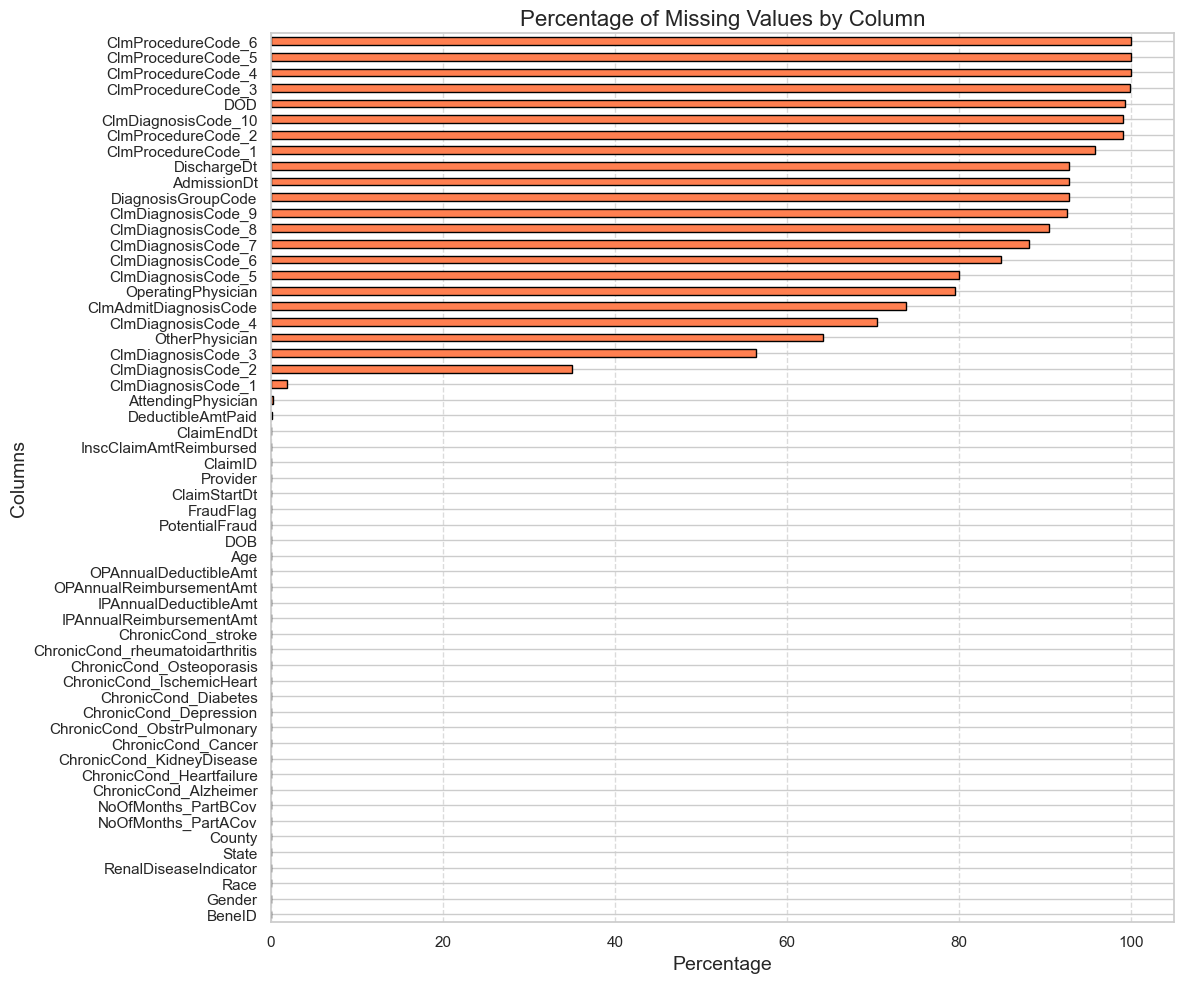

In [426]:
missing_values_percentage = all_data.isna().sum() / len(all_data) * 100

plt.figure(figsize=(12, 10))
missing_values_percentage.sort_values(ascending=True).plot(kind='barh', color='coral', edgecolor='black')
plt.title('Percentage of Missing Values by Column', fontsize=16)
plt.xlabel('Percentage', fontsize=14)
plt.ylabel('Columns', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [427]:
all_data['DOB'] = pd.to_datetime(all_data['DOB'])
all_data['DOD'] = pd.to_datetime(all_data['DOD'])

all_data['Age'] = all_data['DOD'].dt.year - all_data['DOB'].dt.year
all_data.drop(columns=['DOB'], inplace=True)


In [428]:
print(all_data['Age'].value_counts())


Age
67.0    209
69.0    189
73.0    170
77.0    163
68.0    161
       ... 
51.0      6
36.0      5
39.0      4
95.0      3
42.0      2
Name: count, Length: 63, dtype: int64


In [429]:
stats = all_data['Age'].describe()
stats

count    4131.000000
mean       74.509078
std        11.094448
min        36.000000
25%        68.000000
50%        75.000000
75%        82.000000
max       100.000000
Name: Age, dtype: float64

In [430]:
# mean i 50% są bardzo podobne


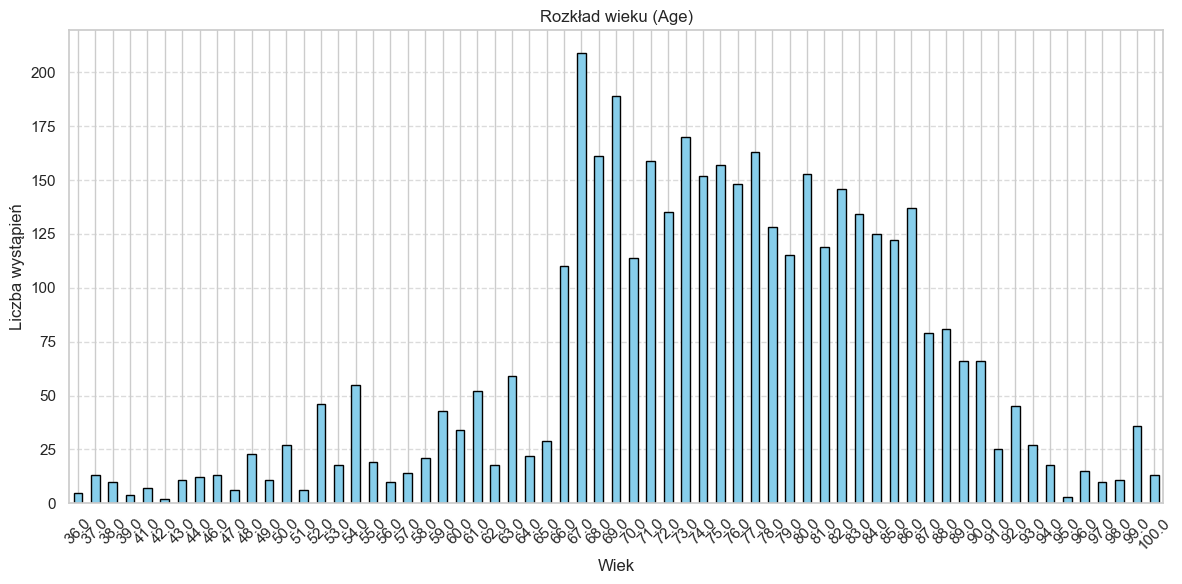

In [431]:
import matplotlib.pyplot as plt

age_counts = all_data['Age'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
age_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Rozkład wieku (Age)')
plt.xlabel('Wiek')
plt.ylabel('Liczba wystąpień')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [432]:
all_data['Age'].fillna(all_data['Age'].median(), inplace=True)


In [433]:
all_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0


In [434]:
print(all_data['PotentialFraud'].isnull().sum())

0


In [435]:
all_data['isAlive'] = all_data['DOD'].isna().astype(int)
all_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag,isAlive
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0,1
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0,1


In [436]:
 #Czy występuje niezrównoważenie klas (np. dużo więcej 0 niż 1)?

print(all_data['PotentialFraud'].value_counts())
print(all_data['PotentialFraud'].value_counts(normalize=True) * 100)


PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64
PotentialFraud
No     61.878931
Yes    38.121069
Name: proportion, dtype: float64


Over/Undesampling wyrównanie klasy - to zalezy przemyślec na podstawie liczby row - przy dużej undersampling, jak mala liczba danych oversampling

In [438]:
# Tak jest więcej nie oszust ok 61% a 38 % jest oszustw

#  Czy kolumna istnieje i ma odpowiedni typ (binary, Yes/No, 0/1)?
#  Czy występuje niezrównoważenie klas (np. dużo więcej 0 niż 1)?
#  Czy klasy są poprawnie zakodowane?

# Tak mamy w provider data dwie kolumny 0/1

In [439]:
#Czy są zduplikowane wiersze (df.duplicated().sum())?

all_data.duplicated().sum()

#Nie ma

0

In [440]:
#Czy są zduplikowane identyfikatory (Provider, ClaimID itd.)?
print('Zduplikowane ClaimID:', all_data['ClaimID'].duplicated().sum())
print('Zduplikowane BeneID:', all_data['BeneID'].duplicated().sum())
print('Zduplikowane Provider:', all_data['Provider'].duplicated().sum())


Zduplikowane ClaimID: 0
Zduplikowane BeneID: 419655
Zduplikowane Provider: 552801


BeneID i Provider się powtarzają. Sprawdzmy ile przeciętnie claimów jest per clienta, a ile jest per clienta frauda.

In [442]:
avg_claims_per_client = all_data.groupby('BeneID')['ClaimID'].nunique().mean()
print(f"Średnia liczba zgłoszeń na klienta: {avg_claims_per_client:.2f}")

# Średnio mamy 4 claimy.

Średnia liczba zgłoszeń na klienta: 4.03


In [443]:

fraud_providers = all_data[all_data['PotentialFraud'] == 'Yes']['Provider'].unique()
fraud_clients = all_data[all_data['Provider'].isin(fraud_providers)]

avg_claims_per_fraud_client = fraud_clients.groupby('BeneID')['ClaimID'].nunique().mean()
print(f"Średnia liczba zgłoszeń na klienta z fraudowym providerem: {avg_claims_per_fraud_client:.2f}")


Średnia liczba zgłoszeń na klienta z fraudowym providerem: 2.53


In [444]:
# Średnia liczba zgłoszen na klienta jest 2.53, czyli raczej ten który nie korzysta intensywnie 

In [445]:
# A co z żyjący i nie żyjący 


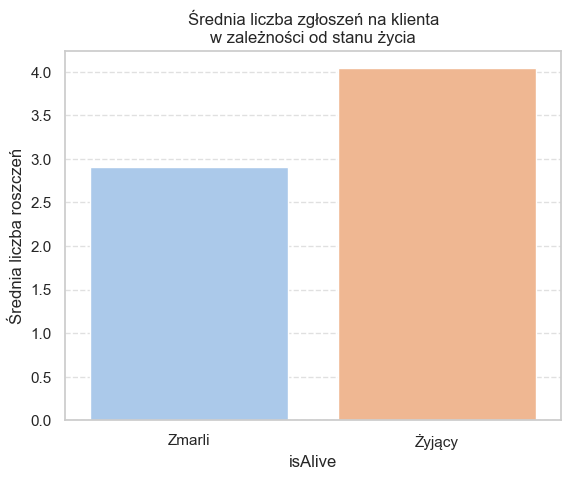

In [446]:
claims_per_client = all_data.groupby(['BeneID', 'isAlive'])['ClaimID'].nunique().reset_index()
avg_claims_alive_status = claims_per_client.groupby('isAlive')['ClaimID'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=avg_claims_alive_status.index, y=avg_claims_alive_status.values, palette='pastel')
plt.xticks([0, 1], ['Zmarli', 'Żyjący'])
plt.ylabel('Średnia liczba roszczeń')
plt.title('Średnia liczba zgłoszeń na klienta\nw zależności od stanu życia')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [447]:
# Więcej fraudów chociaz niewiele więcej jest na żyjących

WasOperated
0    443764
1    114447
Name: count, dtype: int64
WasOperated
0    79.5
1    20.5
Name: proportion, dtype: float64


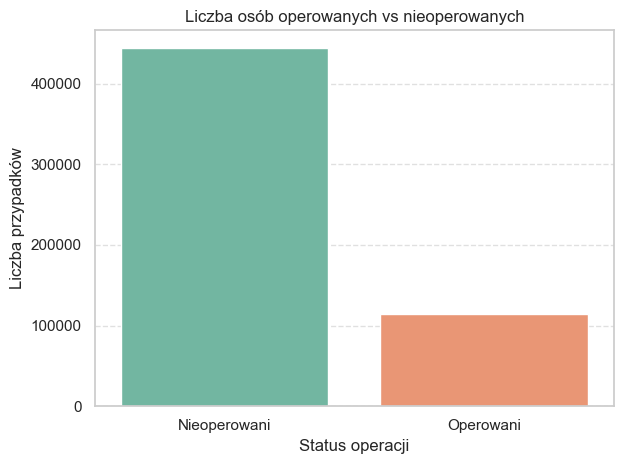

In [448]:
all_data['WasOperated'] = all_data['OperatingPhysician'].notna().astype(int)
operated_counts = all_data['WasOperated'].value_counts()
operated_percent = all_data['WasOperated'].value_counts(normalize=True) * 100
print(operated_counts)
print(operated_percent.round(2))

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='WasOperated', data=all_data, palette='Set2')
plt.xticks([0, 1], ['Nieoperowani', 'Operowani'])
plt.title('Liczba osób operowanych vs nieoperowanych')
plt.ylabel('Liczba przypadków')
plt.xlabel('Status operacji')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [449]:
# Widać wyrażna tendencje że nie operowani raczej jest fraud
# A wrod operowanych to jakie operacje byly sfingwane

In [450]:
fraud_operated = all_data[
    (all_data['WasOperated'] == 1) & 
    (all_data['FraudFlag'] == 1)
]

fraud_by_diag = fraud_operated.groupby('DiagnosisGroupCode')['ClaimID'].count().sort_values(ascending=False)
print(fraud_by_diag.head(10))


DiagnosisGroupCode
286    59
864    55
316    53
252    52
862    51
242    50
244    48
248    48
303    47
307    47
Name: ClaimID, dtype: int64


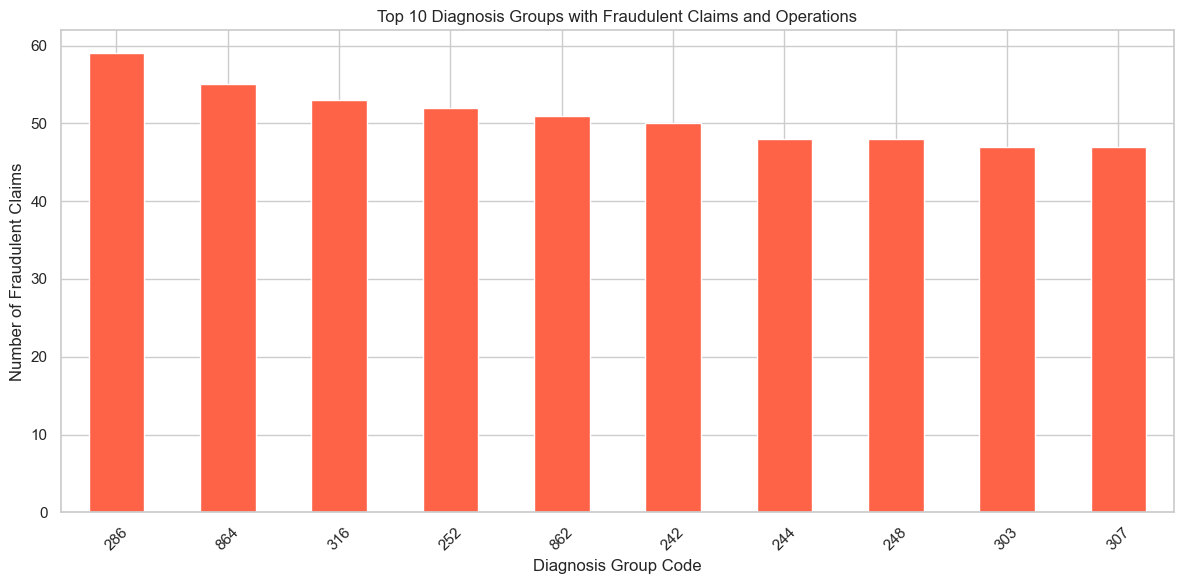

In [451]:
fraud_by_diag.head(10).plot(kind='bar', figsize=(12,6), color='tomato')
plt.title('Top 10 Diagnosis Groups with Fraudulent Claims and Operations')
plt.ylabel('Number of Fraudulent Claims')
plt.xlabel('Diagnosis Group Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [452]:
print(all_data.columns.tolist())

['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'Chron

In [453]:
fraud_with_diag = all_data[
    (all_data['FraudFlag'] == 1) &
    (all_data['DiagnosisGroupCode'].notna())
]

count_fraud_with_diag = fraud_with_diag.shape[0]
print(f"Liczba fraudów z wypełnionym DiagnosisGroupCode: {count_fraud_with_diag}")


Liczba fraudów z wypełnionym DiagnosisGroupCode: 23402


In [454]:
fraud_with_diag = all_data[
    (all_data['FraudFlag'] == 1) &
    (all_data['DiagnosisGroupCode'].notna())
]

all_claims_with_diag = all_data[
    (all_data['DiagnosisGroupCode'].notna())
]
count_fraud_with_diag = fraud_with_diag.shape[0]
total_fraud = all_claims_with_diag.shape[0]

percentage = (count_fraud_with_diag / total_fraud) * 100

print(f"Procent fraudów z wypełnionym DiagnosisGroupCode: {percentage:.2f}%")


Procent fraudów z wypełnionym DiagnosisGroupCode: 57.82%


In [455]:
# Ponad połowe ma wypelnione 57.82%

In [456]:
# A jak od racy fraud zalezy 

Race
1    37.862287
2    36.455787
3    45.457773
5    44.035533
Name: FraudFlag, dtype: float64


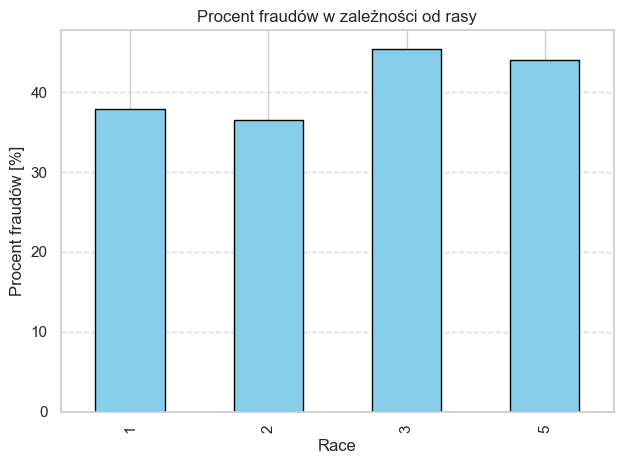

In [457]:
fraud_by_race = all_data.groupby('Race')['FraudFlag'].mean() * 100
print(fraud_by_race)

fraud_by_race.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Procent fraudów w zależności od rasy')
plt.xlabel('Race')
plt.ylabel('Procent fraudów [%]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Najwięcej jest fraudów w rasie 3 i 5
Nie ma wsród fraudow Azjatyckich danych a najwięcej jest fraudow z Hispanic

<Axes: xlabel='Race'>

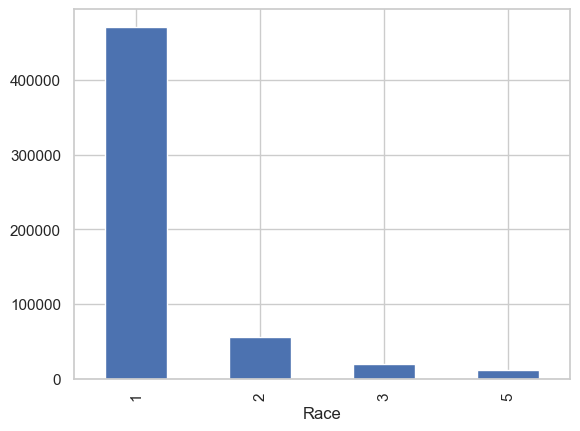

In [459]:
all_data['Race'].value_counts().plot(kind='bar')

In [460]:
fraud_counts_gender = all_data[all_data['FraudFlag'] == 1].groupby('Gender').size()
print(fraud_counts_gender)

Gender
1     89683
2    123113
dtype: int64


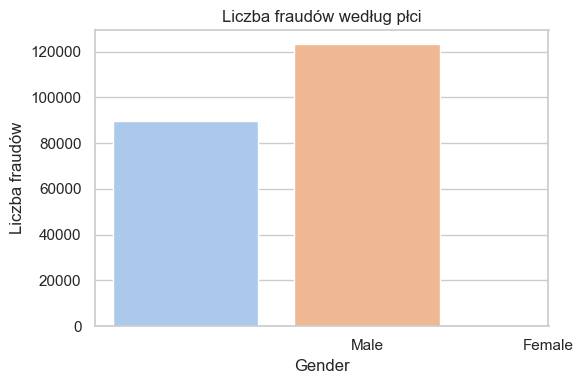

In [461]:
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts_gender.index, y=fraud_counts_gender.values, palette='pastel')
plt.title('Liczba fraudów według płci')
plt.xlabel('Gender')
plt.ylabel('Liczba fraudów')
plt.xticks(ticks=fraud_counts_gender.index, labels=['Male', 'Female']) 
plt.tight_layout()
plt.show()

In [462]:
fraud_ratio_gender = all_data.groupby('Gender')['FraudFlag'].mean() * 100
fraud_ratio_gender

Gender
1    38.147233
2    38.102032
Name: FraudFlag, dtype: float64

Jest więcej fraudow na mezczyznach ilosciowo ale procentowo jest wyrownanie

In [464]:
# Ile per dekada jest fraudow

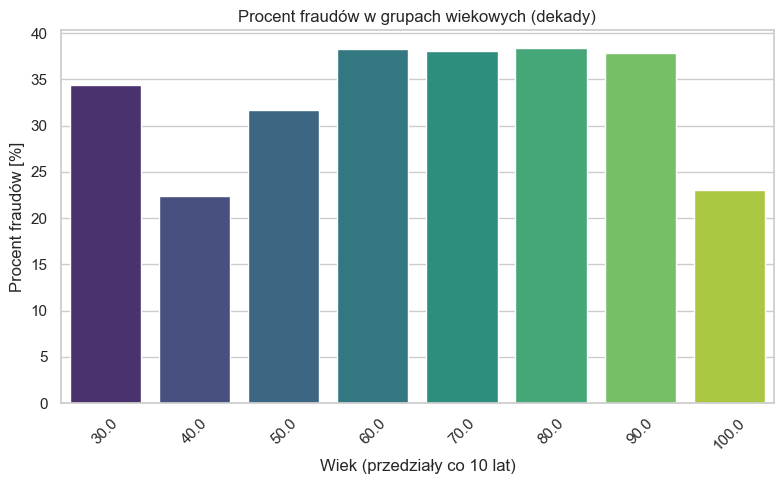

In [465]:
all_data['AgeGroup'] = (all_data['Age'] // 10) * 10

fraud_by_agegroup = all_data[all_data['FraudFlag'] == 1].groupby('AgeGroup').size()
total_by_agegroup = all_data.groupby('AgeGroup').size()
fraud_ratio = (fraud_by_agegroup / total_by_agegroup) * 100

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=fraud_ratio.index, y=fraud_ratio.values, palette='viridis')
plt.title('Procent fraudów w grupach wiekowych (dekady)')
plt.xlabel('Wiek (przedziały co 10 lat)')
plt.ylabel('Procent fraudów [%]')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [466]:
# Najmniej jest fraudow la 40 latkow i 100 latków 

In [467]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

In [468]:
alzheimers = all_data[all_data['ChronicCond_Alzheimer'] == 1]
fraud_ratio_alzheimers = alzheimers['FraudFlag'].mean() * 100
print(f'Procent fraudów wśród chorych na Alzheimera: {fraud_ratio_alzheimers:.2f}%')


Procent fraudów wśród chorych na Alzheimera: 38.49%


In [469]:
chronic_conditions = [
    'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
    'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke'
]

fraud_percentages = {}

for cond in chronic_conditions:
    subset = all_data[all_data[cond] == 1]
    fraud_percent = subset[subset['FraudFlag'] == 1].shape[0] / all_data[all_data['FraudFlag'] == 1].shape[0] * 100
    fraud_percentages[cond] = fraud_percent

fraud_percent_df = pd.DataFrame.from_dict(fraud_percentages, orient='index', columns=['Fraud %']).sort_values(by='Fraud %', ascending=False)
print(fraud_percent_df)

#ile jest fraudow per choroba przewlekla na wszystkie fraudy

                                   Fraud %
ChronicCond_IschemicHeart        76.369857
ChronicCond_Diabetes             70.849546
ChronicCond_Heartfailure         59.609203
ChronicCond_Depression           43.510216
ChronicCond_KidneyDisease        42.222128
ChronicCond_Alzheimer            40.577360
ChronicCond_ObstrPulmonary       32.006241
ChronicCond_Osteoporasis         31.834715
ChronicCond_rheumatoidarthritis  31.411775
ChronicCond_Cancer               15.309498
ChronicCond_stroke               10.524634


Najczęsciej oszukują na chronic 
ChronicCond_IschemicHeart        76.369857
ChronicCond_Diabetes             70.849546
ChronicCond_Heartfailure         59.609203
ChronicCond_Depression           43.510216

In [471]:
all_data.columns


Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

C:\Users\tolki\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


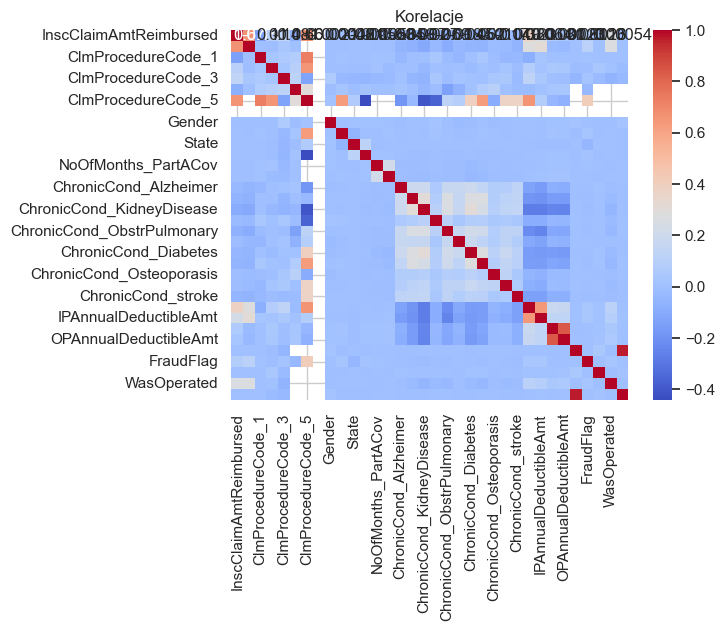

In [472]:
corr_df = all_data.copy()

correlation = corr_df.select_dtypes(include=['number']).corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()


In [473]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

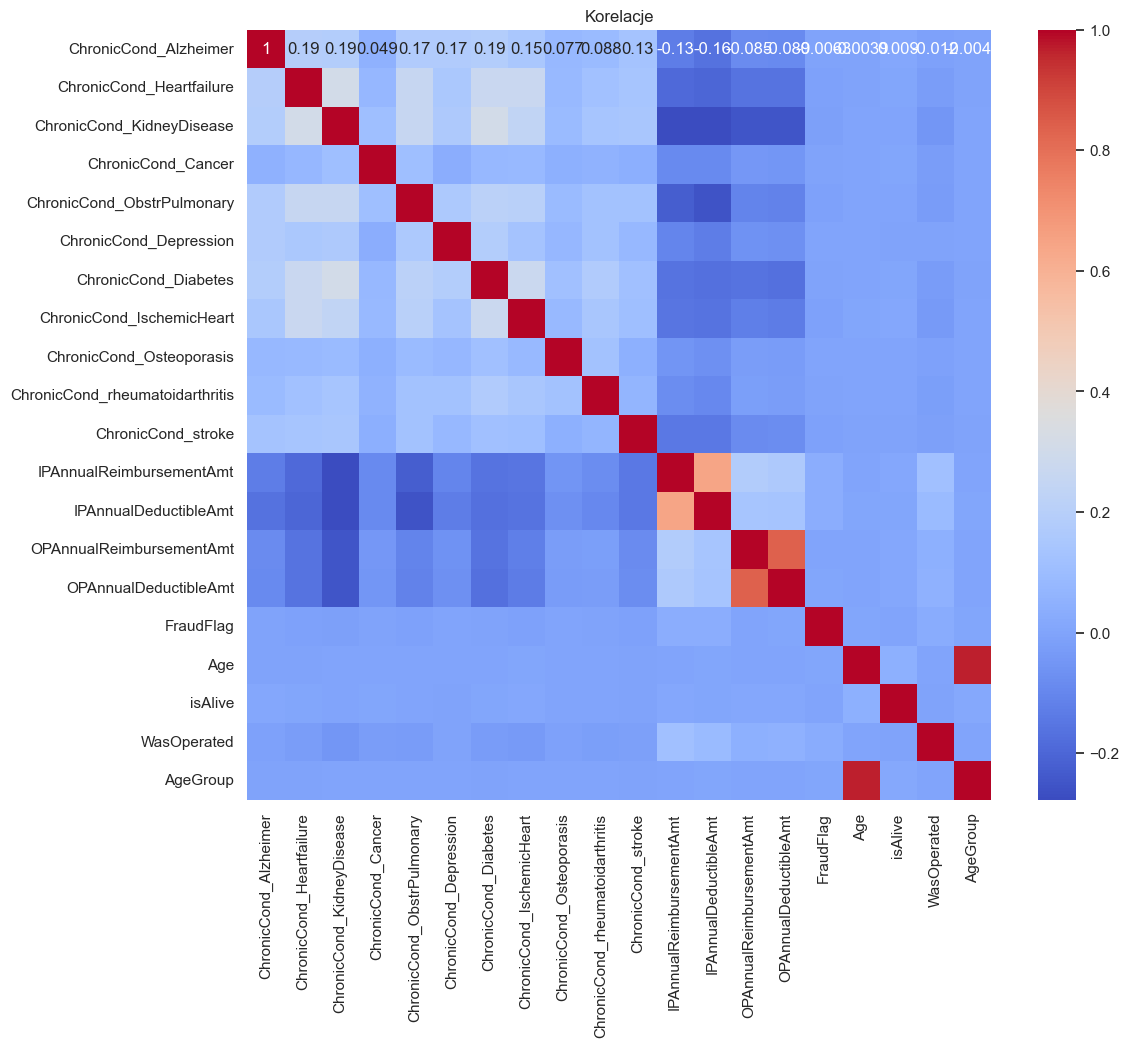

In [474]:
cols = ['ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
        'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
        'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
        'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
        'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
        'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
        'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
        'OPAnnualDeductibleAmt', 'PotentialFraud', 'FraudFlag', 'Age',
        'isAlive', 'WasOperated', 'AgeGroup']

corr_df = all_data[cols]

correlation = corr_df.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

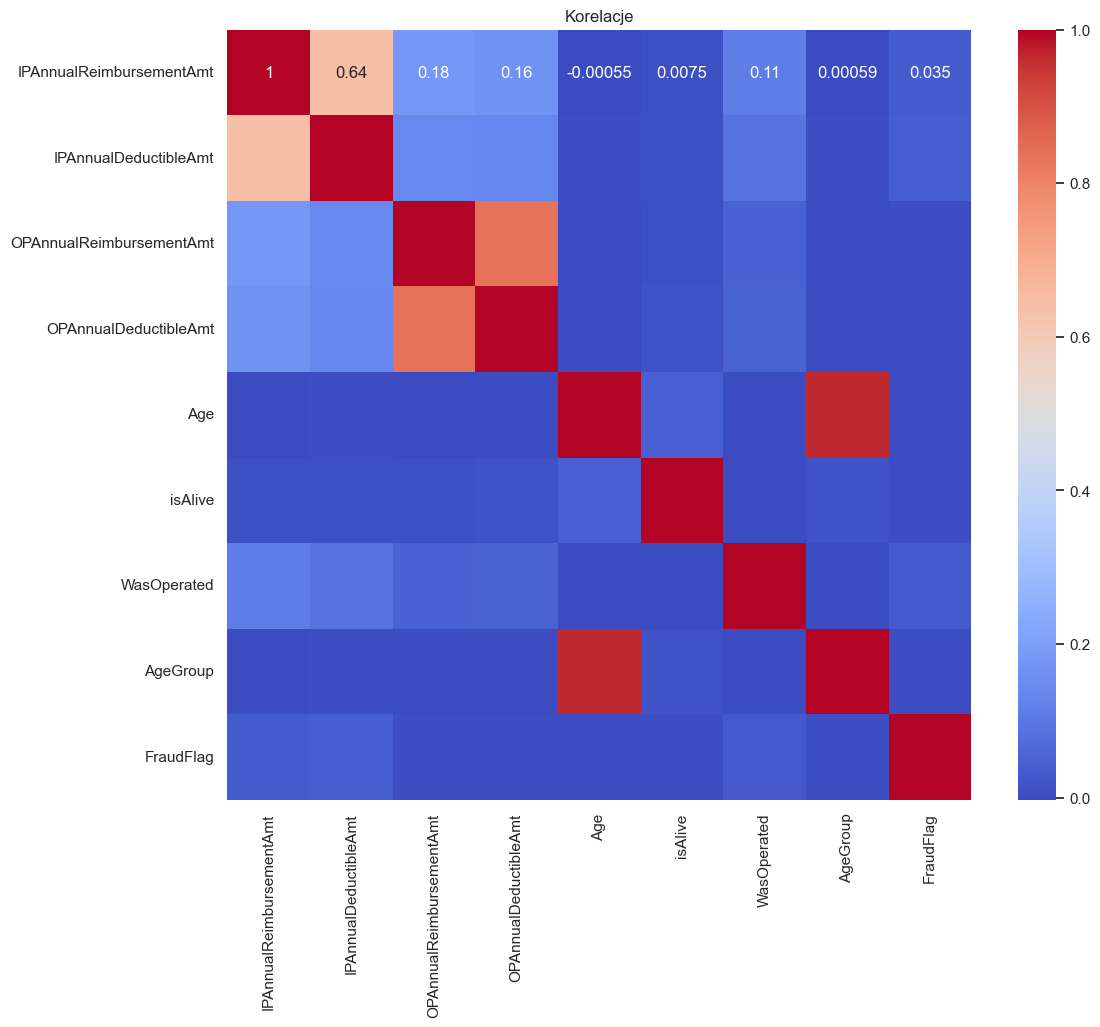

In [475]:
cols = [ 'IPAnnualReimbursementAmt',
        'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
        'OPAnnualDeductibleAmt', 'PotentialFraud', 'Age',
        'isAlive', 'WasOperated', 'AgeGroup', 'FraudFlag']

corr_df = all_data[cols]

correlation = corr_df.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

In [476]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

C:\Users\tolki\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


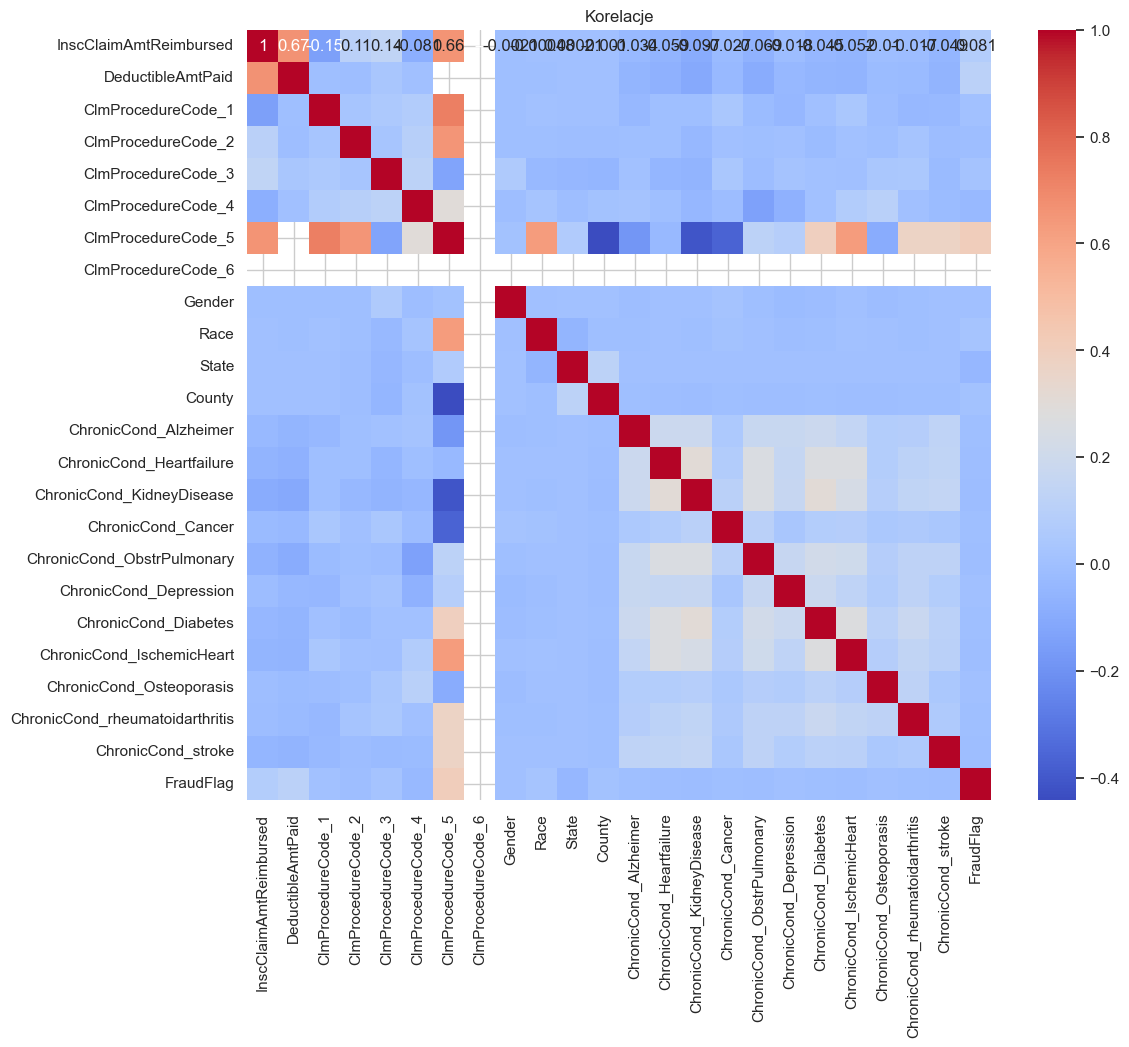

In [477]:
cols = ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke','FraudFlag']

corr_df2 = all_data[cols]

correlation = corr_df2.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

In [478]:
# widaź wyrazna zależnoc CLM_procedure_5

In [479]:
fraud_counts_nonnull = all_data[(all_data['FraudFlag'] == 1) & (all_data['ClmProcedureCode_5'].notna())]['ClmProcedureCode_5'].value_counts()
print(fraud_counts_nonnull)


ClmProcedureCode_5
4139.0    2
5185.0    1
9971.0    1
2724.0    1
9982.0    1
Name: count, dtype: int64


In [480]:
total_counts = all_data['ClmProcedureCode_5'].value_counts(dropna=False)
fraud_counts = all_data[all_data['FraudFlag'] == 1]['ClmProcedureCode_5'].value_counts(dropna=False)

fraud_percent = (fraud_counts / total_counts) * 100
fraud_percent = fraud_percent.sort_values(ascending=False)

print(fraud_percent)


ClmProcedureCode_5
5185.0    100.000000
9971.0    100.000000
9982.0    100.000000
4139.0     66.666667
2724.0     50.000000
NaN        38.120609
4422.0           NaN
Name: count, dtype: float64


In [481]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

In [482]:
#all_data = all_data.drop(['ClaimStartDt', 'ClaimEndDt','PotentialFraud', 'AgeGroup', 'DOD', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov','OPAnnualDeductibleAmt', 'IPAnnualDeductibleAmt'],axis=1)
all_data = all_data.drop(['ClaimStartDt', 'ClaimEndDt'],axis=1)


In [483]:
all_data.columns

Index(['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
       'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid',
       'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
       'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
       'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
       'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
       'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DOD',
       'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County',
       'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer',
       'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease',
       'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary',
       'ChronicCond_Depression', 'ChronicCond_Diabetes',
       'ChronicCond_IschemicHea

In [484]:
all_data = all_data.drop(['DeductibleAmtPaid'],axis=1)

C:\Users\tolki\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


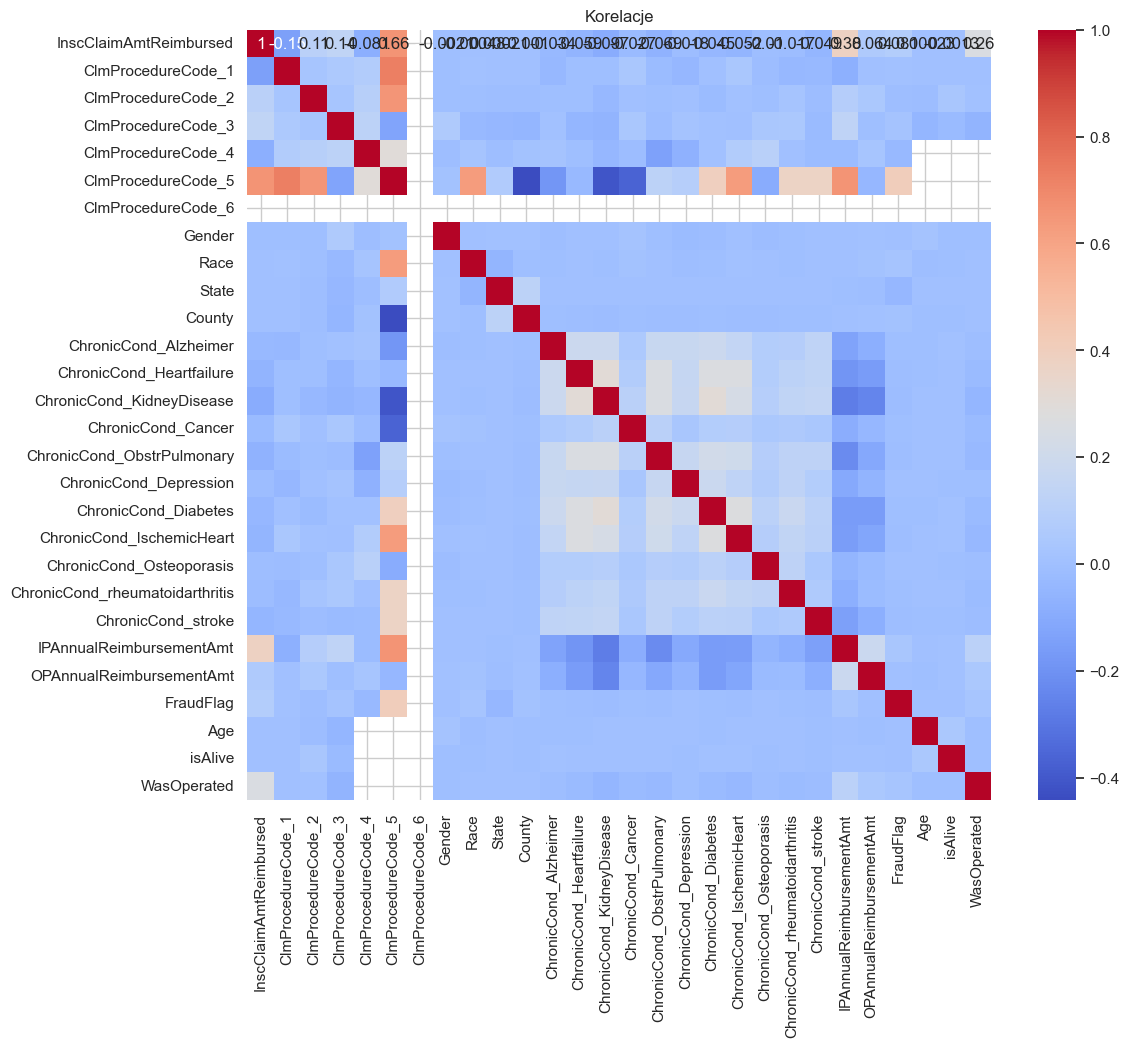

In [485]:
cols = ['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
       'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
       'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
       'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
       'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
       'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',
       'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'OPAnnualReimbursementAmt', 'FraudFlag', 'Age', 'isAlive',
       'WasOperated']

corr_df3 = all_data[cols]

correlation = corr_df3.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

In [486]:
# Melt: przekształcenie danych z szerokiego formatu do długiego
all_data_melted = all_data.melt(var_name='original_column', value_name='value')
# Dodanie nowej kolumny z ostatnią literą nazwy kolumny
all_data_melted['last_letter'] = all_data_melted['original_column'].str[-1]



In [487]:
print(all_data_melted.head())

  original_column      value last_letter
0          BeneID  BENE11001           D
1          BeneID  BENE11001           D
2          BeneID  BENE11001           D
3          BeneID  BENE11011           D
4          BeneID  BENE11014           D


In [488]:



# Wybierz kolumny, których nazwa kończy się cyfrą 1-9
digit_cols = ['ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10']
# Stwórz pustą kolumnę docelową
all_data['digit_found'] = None
# Iteruj po wybranych kolumnach i przypisz cyfrę tam, gdzie wartość == 1
for col in digit_cols:
    digit = col[-1]
    mask = all_data[col] == 1
    all_data.loc[mask, 'digit_found'] = digit
display(all_data.head())

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag,isAlive,WasOperated,AgeGroup,digit_found
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1,1,0,70.0,None
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,1,70.0,None
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,0,70.0,None
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0,1,1,70.0,None
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0,1,1,70.0,None


In [489]:
display(all_data.head())

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag,isAlive,WasOperated,AgeGroup,digit_found
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1,1,0,70.0,None
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,1,70.0,None
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,0,70.0,None
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0,1,1,70.0,None
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0,1,1,70.0,None


Analiza ze względu na rasę beneficjenta

In [491]:
fraud_percentage_df = all_data.groupby('Race')['FraudFlag'].mean().reset_index()
fraud_percentage_df['FraudFlag'] = fraud_percentage_df['FraudFlag'] * 100
fraud_percentage_df.rename(columns={'FraudFlag': 'Fraud Percentage'}, inplace=True)

print(fraud_percentage_df)


   Race  Fraud Percentage
0     1         37.862287
1     2         36.455787
2     3         45.457773
3     5         44.035533


In [492]:
fraud_percentage_df = all_data.groupby(['Race', 'AgeGroup']).agg(
    FraudFlag_mean=('FraudFlag', 'mean'),
    count=('FraudFlag', 'size')  # liczba wierszy w grupie
).reset_index()
fraud_percentage_df['FraudFlag_mean'] = fraud_percentage_df['FraudFlag_mean'] * 100
fraud_percentage_df.rename(columns={'FraudFlag_mean': 'Fraud Percentage'}, inplace=True)

print(fraud_percentage_df)

    Race  AgeGroup  Fraud Percentage   count
0      1      30.0         38.095238      21
1      1      40.0         25.925926      54
2      1      50.0         29.268293     205
3      1      60.0         40.486409     699
4      1      70.0         37.862903  468823
5      1      80.0         38.680203     985
6      1      90.0         36.440678     236
7      1     100.0         23.076923      13
8      2      30.0         27.272727      11
9      2      40.0         17.857143      28
10     2      50.0         35.483871      31
11     2      60.0         31.683168     101
12     2      70.0         36.480555   55361
13     2      80.0         32.352941     102
14     2      90.0         66.666667       6
15     3      50.0         75.000000       4
16     3      60.0         29.824561      57
17     3      70.0         45.503212   19614
18     3      80.0         41.935484      31
19     3      90.0         44.444444       9
20     5      40.0          0.000000       3
21     5  

# Rasa nie ma znaczącego wpływu na oszustwa

In [494]:
cols = [
    'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
    'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
    'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
    'ClmDiagnosisCode_10'
]

# Tworzymy nową kolumnę 'DiagnosisCount' zliczającą ile jest wartości nie-NaN w tych kolumnach
all_data['DiagnosisCount'] = all_data[cols].notnull().sum(axis=1)

# Sprawdź efekt
print(all_data[['DiagnosisCount']].head())

   DiagnosisCount
0               9
1               3
2               6
3               9
4               9


In [495]:
cols = [
    'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
    'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',
]

# Tworzymy nową kolumnę 'ProceduresCount' zliczającą ile jest wartości nie-NaN w tych kolumnach
all_data['ProceduresCount'] = all_data[cols].notnull().sum(axis=1)

# Sprawdź efekt
print(all_data[['ProceduresCount']].head())

   ProceduresCount
0                0
1                1
2                0
3                1
4                1


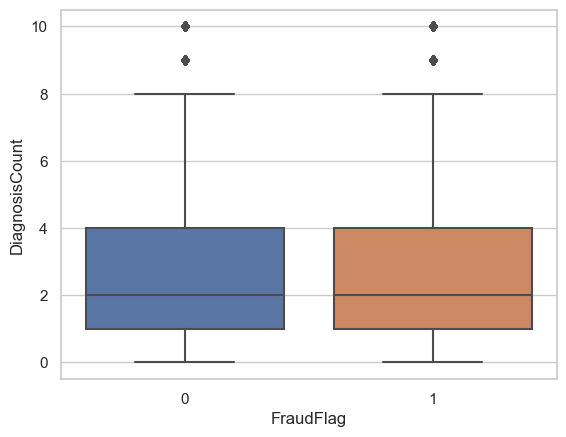

Korelacja Pearsona między DiagnosisCount a FraudFlag: 0.06552380768356796


In [496]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='FraudFlag', y='DiagnosisCount', data=all_data)
plt.show()

correlation = all_data['DiagnosisCount'].corr(all_data['FraudFlag'])
print(f"Korelacja Pearsona między DiagnosisCount a FraudFlag: {correlation}")

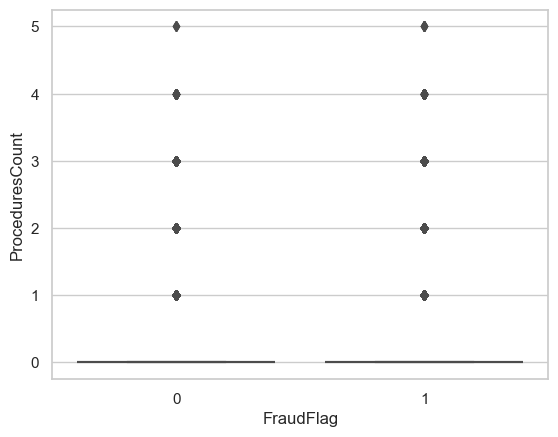

Korelacja Pearsona między ProceduresCount a FraudFlag: 0.07912935793651145


In [497]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='FraudFlag', y='ProceduresCount', data=all_data)
plt.show()

correlation = all_data['ProceduresCount'].corr(all_data['FraudFlag'])
print(f"Korelacja Pearsona między ProceduresCount a FraudFlag: {correlation}")

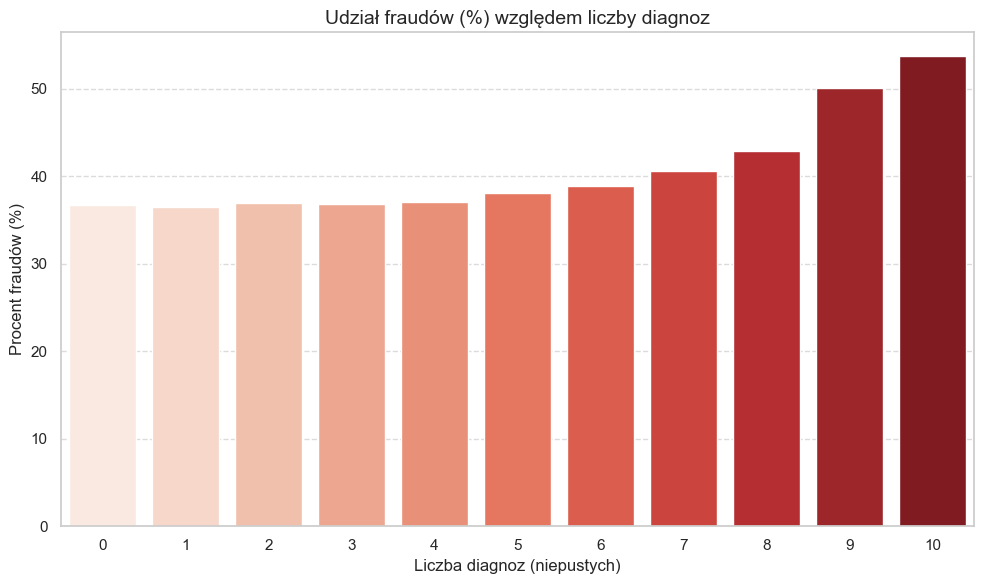

In [498]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
diag_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]
all_data['DiagCount'] = all_data[diag_cols].notna().sum(axis=1)
all_data['FraudFlag'] = pd.to_numeric(all_data['FraudFlag'], errors='coerce')
summary = all_data.groupby('DiagCount')['FraudFlag'].agg(['sum', 'count']).reset_index()
summary['FraudPercent'] = (summary['sum'] / summary['count']) * 100
plt.figure(figsize=(10, 6))
sns.barplot(data=summary, x='DiagCount', y='FraudPercent', palette='Reds')
plt.title('Udział fraudów (%) względem liczby diagnoz', fontsize=14)
plt.xlabel('Liczba diagnoz (niepustych)', fontsize=12)
plt.ylabel('Procent fraudów (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

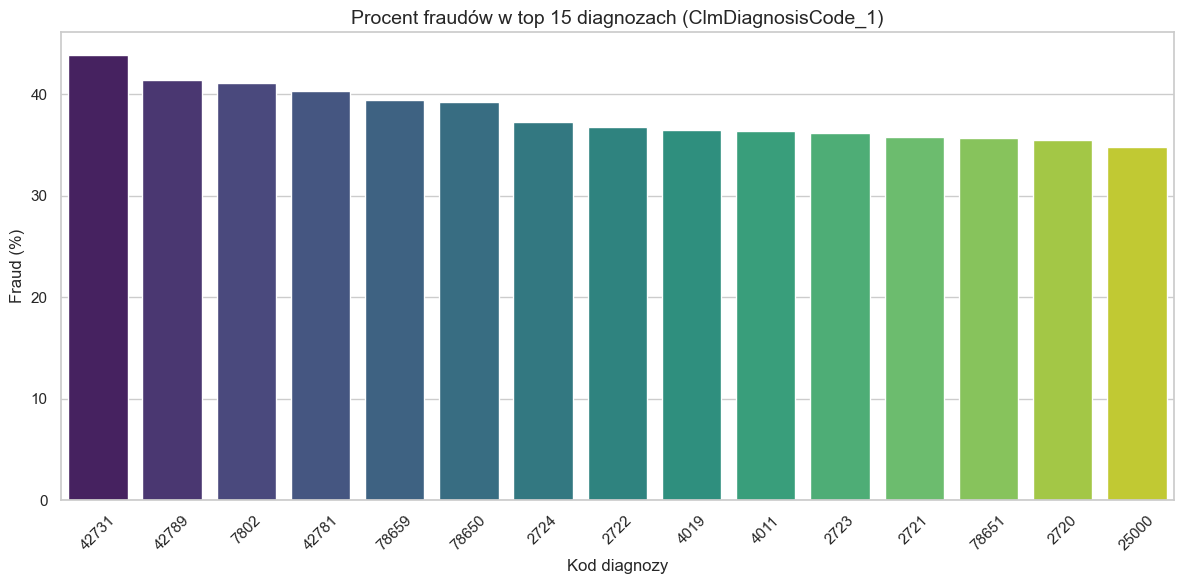

In [499]:
top_15 = (
    all_data['ClmDiagnosisCode_1']
    .value_counts()
    .head(15)
    .index
)
df_top15 = all_data[all_data['ClmDiagnosisCode_1'].isin(top_15)]
diag_summary = (
    df_top15
    .groupby('ClmDiagnosisCode_1')['FraudFlag']
    .agg(
        total='count',
        fraud_count='sum'
    )
    .reset_index()
)
diag_summary['fraud_percent'] = (diag_summary['fraud_count'] / diag_summary['total']) * 100
diag_summary = diag_summary.sort_values(by='fraud_percent', ascending=False)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(
    data=diag_summary,
    x='ClmDiagnosisCode_1',
    y='fraud_percent',
    palette='viridis'
)
plt.title('Procent fraudów w top 15 diagnozach (ClmDiagnosisCode_1)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

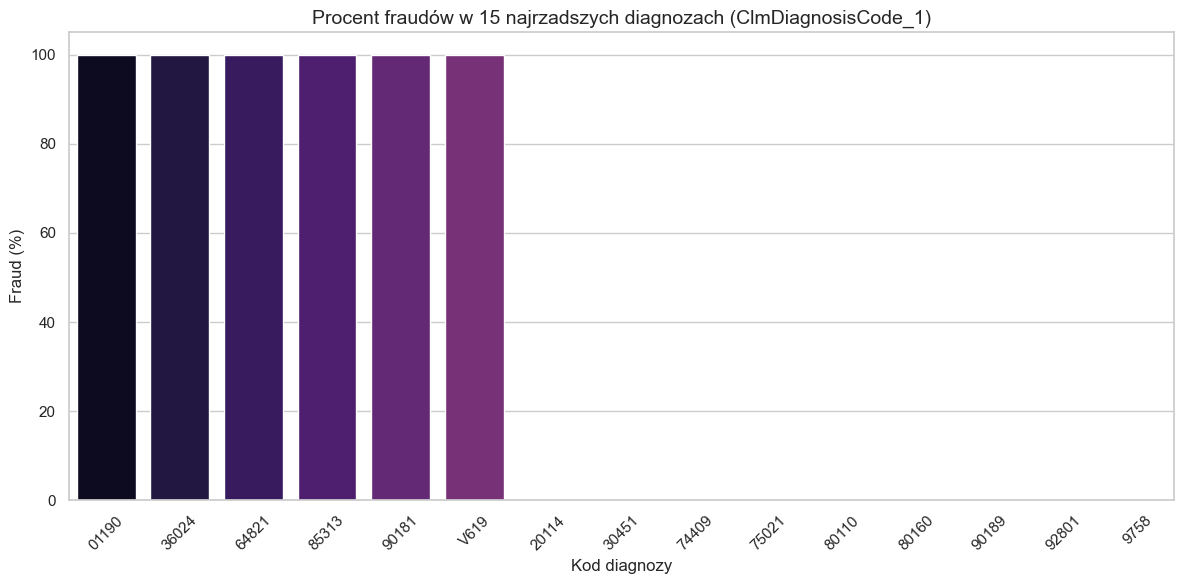

In [500]:
# Znajdź 15 najrzadszych diagnoz (pomijając NaN)
rare_15 = (
    all_data['ClmDiagnosisCode_1']
    .value_counts(ascending=True)
    .dropna()
    .head(15)
    .index
)
# Filtrowanie danych tylko do tych diagnoz
df_rare15 = all_data[all_data['ClmDiagnosisCode_1'].isin(rare_15)]
# Podsumowanie fraudów i liczby przypadków
rare_diag_summary = (
    df_rare15
    .groupby('ClmDiagnosisCode_1')['FraudFlag']
    .agg(
        total='count',
        fraud_count='sum'
    )
    .reset_index()
)
rare_diag_summary['fraud_percent'] = (rare_diag_summary['fraud_count'] / rare_diag_summary['total']) * 100
rare_diag_summary = rare_diag_summary.sort_values(by='fraud_percent', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=rare_diag_summary,
    x='ClmDiagnosisCode_1',
    y='fraud_percent',
    palette='magma'
)
plt.title('Procent fraudów w 15 najrzadszych diagnozach (ClmDiagnosisCode_1)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

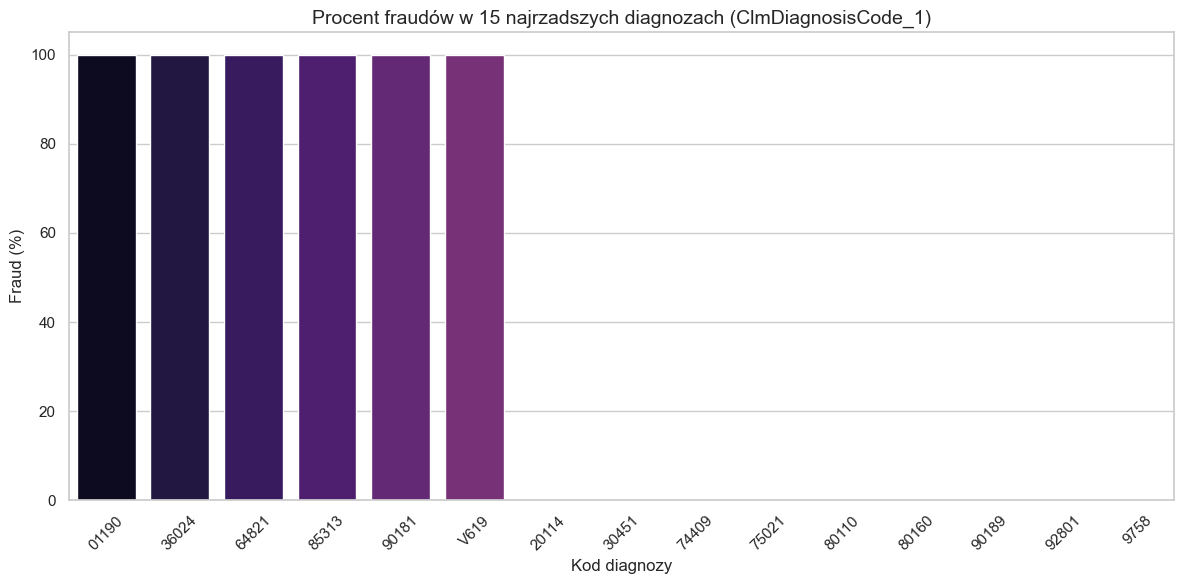

In [501]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=rare_diag_summary,
    x='ClmDiagnosisCode_1',
    y='fraud_percent',
    palette='magma'
)
plt.title('Procent fraudów w 15 najrzadszych diagnozach (ClmDiagnosisCode_1)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

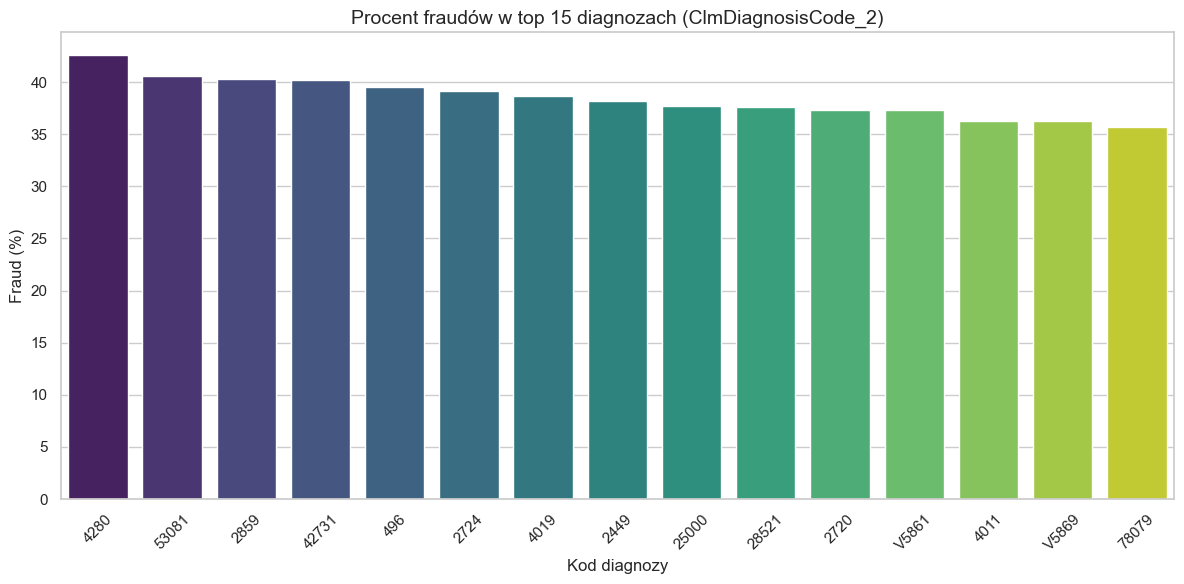

In [502]:
top_15_2= (
    all_data['ClmDiagnosisCode_2']
    .value_counts()
    .head(15)
    .index
)
df_top15 = all_data[all_data['ClmDiagnosisCode_2'].isin(top_15_2)]
diag_summary = (
    df_top15
    .groupby('ClmDiagnosisCode_2')['FraudFlag']
    .agg(
        total='count',
        fraud_count='sum'
    )
    .reset_index()
)
diag_summary['fraud_percent'] = (diag_summary['fraud_count'] / diag_summary['total']) * 100
diag_summary = diag_summary.sort_values(by='fraud_percent', ascending=False)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(
    data=diag_summary,
    x='ClmDiagnosisCode_2',
    y='fraud_percent',
    palette='viridis'
)
plt.title('Procent fraudów w top 15 diagnozach (ClmDiagnosisCode_2)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [503]:
#Analiza fraudów według lekarzy (AttendingPhysician, OperatingPhysician, OtherPhysician)
# Top 10 lekarzy z największą liczbą fraudów
top_phys_frauds = all_data[all_data['PotentialFraud'] == 'Yes'] \
    ['AttendingPhysician'].value_counts().head(10)
print(top_phys_frauds)
top_phys_ids = top_phys_frauds.index.tolist()
top_phys_data = all_data[all_data['AttendingPhysician'].isin(top_phys_ids)]

AttendingPhysician
PHY330576    2534
PHY350277    1628
PHY412132    1321
PHY423534    1223
PHY314027    1200
PHY327046    1181
PHY338032    1158
PHY357120    1156
PHY337425    1156
PHY341578    1133
Name: count, dtype: int64


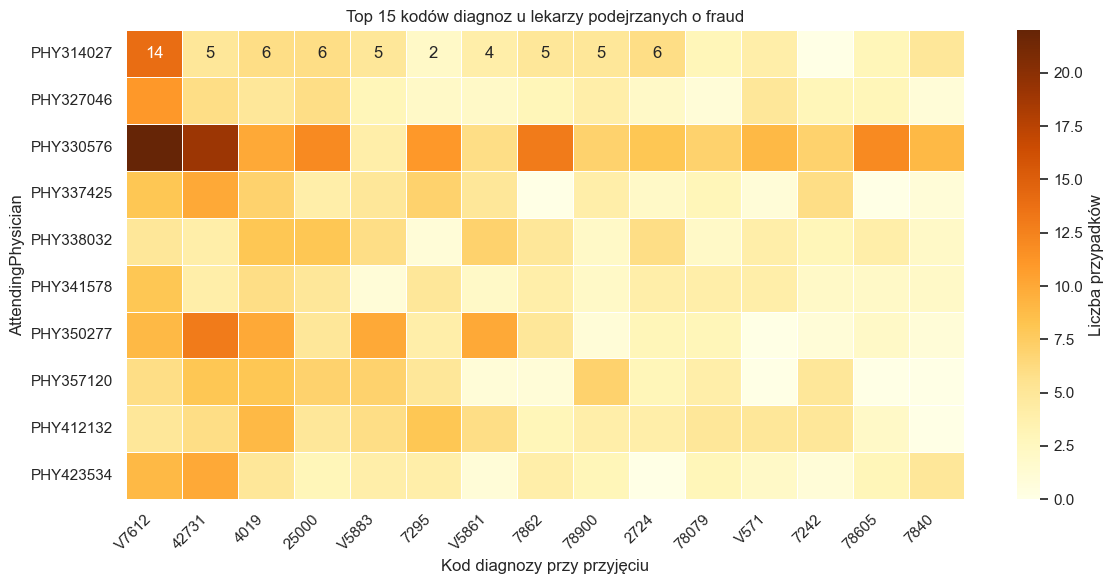

In [504]:
fraud_phys_data = all_data[
    (all_data['PotentialFraud'] == 'Yes') &
    (all_data['AttendingPhysician'].isin(top_phys_ids))
]
fraud_diag_crosstab = pd.crosstab(fraud_phys_data['AttendingPhysician'], fraud_phys_data['ClmAdmitDiagnosisCode'])

# Wyciągnij top 15 najczęstszych kodów diagnozy wśród tych lekarzy
top_diag_codes = fraud_phys_data['ClmAdmitDiagnosisCode'].value_counts().head(15).index
# Filtrowanie tabeli tylko do tych kodów
filtered_crosstab = fraud_diag_crosstab[top_diag_codes]

plt.figure(figsize=(12, 6))
sns.heatmap(filtered_crosstab, cmap='YlOrBr', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Liczba przypadków'})
plt.title("Top 15 kodów diagnoz u lekarzy podejrzanych o fraud")
plt.xlabel("Kod diagnozy przy przyjęciu")
plt.ylabel("AttendingPhysician")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [505]:
print('########################')

########################


In [506]:
##### przygotowanie

all_data["RenalDiseaseIndicator2"] = all_data["RenalDiseaseIndicator"].map({
    "Y": 1,
    "N": 0,
    "0": np.nan
})

kolumny = [
    'InscClaimAmtReimbursed',
    #'NoOfMonths_PartACov',
    #'NoOfMonths_PartBCov',
    'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt',
    'Age',
    'DiagnosisCount',
    'ProceduresCount',
    'WasOperated',
    'Gender',
    'Race',
    'RenalDiseaseIndicator2'
]

X = all_data[kolumny]
y = all_data['FraudFlag']

In [663]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

##### skalowanie
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#####  treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.2, random_state=42
)


scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print('done')

done


In [326]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd
from sklearn.model_selection import GridSearchCV

print('start twrenowania modeli')

# Bazowy model
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

# Zoptymalizowana siatka hiperparametrów (dużo mniejsza)
param_dist = {
    'n_estimators': [ 300, 500],                      # 3
    'learning_rate': [0.05, 0.1, 0.2],                    # 3
    'max_depth': [10, 20],                             # 3 (29 to overfitting, testuj szerzej)
    'min_child_weight': [1, 3],                           # 2
    'gamma': [0, 0.1],                                    # 2
    'subsample': [0.8, 1.0],                              # 2
    'colsample_bytree': [0.8, 1.0],                       # 2
    'reg_alpha': [0, 0.1],                                # 2
    'reg_lambda': [1, 5],                                 # 2
    'scale_pos_weight': [1, 5],                           # 2
    'grow_policy': ['depthwise']                          # 1 (szybsze i stabilniejsze)
}

# GridSearchCV
random_search = GridSearchCV(
    estimator=model,
    param_grid=param_dist,    # <- ta sama siatka, ale teraz to param_grid
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=1,
    return_train_score=False
)

"""
# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=80,            # Losowo testuje tylko 50 kombinacji!
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    return_train_score=False
)
"""

# Trenowanie
random_search.fit(X_train, y_train)

# Wyniki każdego modelu
results_df = pd.DataFrame(random_search.cv_results_).sort_values(by='rank_test_score')
results_df = results_df[['rank_test_score', 'mean_test_score', 'params']]
results_df = results_df.rename(columns={'mean_test_score': 'mean_roc_auc'})

# Wyświetlanie wyników
print("\n=== Wszystkie modele (posegregowane wg ROC AUC) ===\n")
for idx, row in results_df.iterrows():
    print(f"Model #{row['rank_test_score']}:")
    print(f"ROC AUC: {row['mean_roc_auc']:.4f}")
    print(f"Parametry: {row['params']}")
    print("-" * 60)

# Najlepszy model
best_model = random_search.best_estimator_

# Predykcje na danych testowych
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Metryki końcowe
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, digits=4)

# === PODSUMOWANIE ===
print("\n=== Najlepszy model ===")
print("Parametry (pełne):")
for param, value in best_model.get_params().items():
    print(f"{param}: {value}")

print("\n=== Metryki najlepszego modelu ===")
print("F1 Score:", f1)
print("ROC AUC Score:", auc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", cr)

print('Koniec trenowania')

start twrenowania modeli
Fitting 3 folds for each of 1536 candidates, totalling 4608 fits


C:\Users\tolki\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:04:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, gamma=0, grow_policy=depthwise, learning_rate=0.05, max_depth=10, min_child_weight=1, n_estimators=300, reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.8; total time=   4.7s


C:\Users\tolki\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:04:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, gamma=0, grow_policy=depthwise, learning_rate=0.05, max_depth=10, min_child_weight=1, n_estimators=300, reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=0.8; total time=   4.3s


...

[CV] END colsample_bytree=1.0, gamma=0.1, grow_policy=depthwise, learning_rate=0.2, max_depth=20, min_child_weight=3, n_estimators=500, reg_alpha=0.1, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=   8.0s


C:\Users\tolki\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:25:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.1, grow_policy=depthwise, learning_rate=0.2, max_depth=20, min_child_weight=3, n_estimators=500, reg_alpha=0.1, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=   7.5s


C:\Users\tolki\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:25:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Wszystkie modele (posegregowane wg ROC AUC) ===

Model #1:
ROC AUC: 0.6425
Parametry: {'colsample_bytree': 0.8, 'gamma': 0, 'grow_policy': 'depthwise', 'learning_rate': 0.05, 'max_depth': 20, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 1, 'scale_pos_weight': 1, 'subsample': 1.0}
------------------------------------------------------------
Model #2:
ROC AUC: 0.6413
Parametry: {'colsample_bytree': 0.8, 'gamma': 0, 'grow_policy': 'depthwise', 'learning_rate': 0.05, 'max_depth': 20, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'scale_pos_weight': 1, 'subsample': 1.0}
------------------------------------------------------------
Model #3:
ROC AUC: 0.6411
Parametry: {'colsample_bytree': 0.8, 'gamma': 0, 'grow_policy': 'depthwise', 'learning_rate': 0.05, 'max_depth': 20, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1, 'scale_pos_weight': 1, 'subsample': 1.0}
---------------------------------------

In [ ]:
''''
TN (True Negative) = 61405 → Model poprawnie przewidział 0, gdy rzeczywiste też było 0.
FP (False Positive) = 7678 → Model przewidział 1, ale rzeczywiste było 0 (fałszywy alarm).
FN (False Negative) = 30376 → Model przewidział 0, ale rzeczywiste było 1 (przegapił pozytywny przypadek).
TP (True Positive) = 12184 → Model poprawnie przewidział 1, gdy rzeczywiste też było 1.
''''

In [330]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
from itertools import product
import pandas as pd

# === Rozsądna siatka parametrów przeciwdziałająca overfittingowi ===
param_grid = {
    'learning_rate': [0.03, 0.05],
    'n_estimators': [300, 500],
    'max_depth': [6, 10, 15],                 # ograniczenie głębokości
    'min_child_weight': [3, 5],               # większa wartość = mniej dopasowania
    'gamma': [0.1, 0.3],                      # odrzuca słabe podziały
    'subsample': [0.7, 0.9],                  # losowy sampling rekordów
    'colsample_bytree': [0.7, 0.9],           # sampling kolumn
    'reg_alpha': [0.1],                       # L1 regularizacja
    'reg_lambda': [5],                        # L2 regularizacja
    'scale_pos_weight': [5]                   # jeśli dane są niezbalansowane
}



param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

results = []

print(f"🔁 Testowanie {len(param_combinations)} kombinacji (przeciw overfittingowi)...")

for idx, combo in enumerate(param_combinations, 1):
    params = dict(zip(param_names, combo))
    
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        random_state=42,
        **params
    )
    
    print(f"\n🚀 Model {idx}/{len(param_combinations)}: {params}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"🔹 F1 Score: {f1:.4f} | ROC AUC: {auc:.4f}")
    
    results.append({
        'model_index': idx,
        'f1_score': f1,
        'roc_auc': auc,
        'params': params
    })

# === Podsumowanie wyników ===
results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)

print("\n✅ TOP 5 modeli bez przeuczenia:")
print(results_df.head(5).to_string(index=False))

🔁 Testowanie 192 kombinacji (przeciw overfittingowi)...

🚀 Model 1/192: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 6, 'min_child_weight': 3, 'gamma': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 5, 'scale_pos_weight': 5}
🔹 F1 Score: 0.5521 | ROC AUC: 0.5696

🚀 Model 2/192: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 6, 'min_child_weight': 3, 'gamma': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 5, 'scale_pos_weight': 5}
🔹 F1 Score: 0.5521 | ROC AUC: 0.5707

🚀 Model 3/192: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 6, 'min_child_weight': 3, 'gamma': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 5, 'scale_pos_weight': 5}
🔹 F1 Score: 0.5521 | ROC AUC: 0.5704

🚀 Model 4/192: {'learning_rate': 0.03, 'n_estimators': 300, 'max_depth': 6, 'min_child_weight': 3, 'gamma': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda':

In [336]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from itertools import product
import pandas as pd

# === Rozsądna siatka parametrów przeciwdziałająca overfittingowi ===
param_grid = {
    'learning_rate': [0.01, 0.02, 0.03],
    'n_estimators': [800, 1000],
    'max_depth': [15, 20],
    'min_child_weight': [3, 5],
    'gamma': [0.3],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0.1],
    'reg_lambda': [5],
    'scale_pos_weight': [5]
}

param_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

results = []

print(f"🔁 Testowanie {len(param_combinations)} kombinacji (przeciw overfittingowi)...")

for idx, combo in enumerate(param_combinations, 1):
    params = dict(zip(param_names, combo))

    print(f"\n🚀 Model {idx}/{len(param_combinations)}: {params}")

    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        random_state=42,
        **params
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, digits=4)

    print(f"🔹 F1 Score: {f1:.4f} | ROC AUC: {auc:.4f}")
    print("🔸 Confusion Matrix:\n", cm)
    print("🔸 Classification Report:\n", cr)

    results.append({
        'model_index': idx,
        'f1_score': f1,
        'roc_auc': auc,
        'params': params,
        'confusion_matrix': cm,
        'classification_report': cr
    })

# === Podsumowanie wyników ===
results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)

print("\n✅ TOP 5 modeli bez przeuczenia:")
for i, row in results_df.head(5).iterrows():
    print(f"\n🏆 Model #{row['model_index']}")
    print(f"ROC AUC: {row['roc_auc']:.4f} | F1 Score: {row['f1_score']:.4f}")
    print("Parametry:", row['params'])
    print("Confusion Matrix:\n", row['confusion_matrix'])
    print("Classification Report:\n", row['classification_report'])
    print("-" * 70)

🔁 Testowanie 144 kombinacji (przeciw overfittingowi)...

🚀 Model 1/144: {'learning_rate': 0.01, 'n_estimators': 800, 'max_depth': 15, 'min_child_weight': 3, 'gamma': 0.3, 'subsample': 0.8, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 5, 'scale_pos_weight': 5}
🔹 F1 Score: 0.5549 | ROC AUC: 0.6406
🔸 Confusion Matrix:
 [[ 1247 67836]
 [  168 42392]]
🔸 Classification Report:
               precision    recall  f1-score   support

           0     0.8813    0.0181    0.0354     69083
           1     0.3846    0.9961    0.5549     42560

    accuracy                         0.3909    111643
   macro avg     0.6329    0.5071    0.2951    111643
weighted avg     0.6919    0.3909    0.2334    111643


🚀 Model 2/144: {'learning_rate': 0.01, 'n_estimators': 800, 'max_depth': 15, 'min_child_weight': 3, 'gamma': 0.3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 5, 'scale_pos_weight': 5}
🔹 F1 Score: 0.5553 | ROC AUC: 0.6433
🔸 Confusion Matrix:
 [[ 1431 6765

In [176]:
##########    wybranie optymalnego modelu
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
conf_best = confusion_matrix(y_test, y_pred_best)
report_best = classification_report(y_test, y_pred_best, digits=4)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print("\n====== ✅ NAJLEPSZY MODEL ======")
print(f"🔢 Model nr: {best_row['model_nr']}")
print(f"🛠 Max Depth: {best_row['max_depth']}")
print(f"⚙️ Learning Rate: {best_row['learning_rate']:.2f}")
print(f"🏅 ROC AUC: {roc_auc_best:.4f}")
print(f"🏅 F1 Score: {f1_best:.4f}")
print("\n🧾 Confusion Matrix:\n", conf_best)
print("\n🧾 Classification Report:\n", report_best)

#### wynik minialnie wyższy niz losowy


====== ✅ NAJLEPSZY MODEL ======
🔢 Model nr: 1
🛠 Max Depth: 29
⚙️ Learning Rate: 0.11
🏅 ROC AUC: 0.6537
🏅 F1 Score: 0.5113

🧾 Confusion Matrix:
 [[48960 20123]
 [21029 21531]]

🧾 Classification Report:
               precision    recall  f1-score   support

           0     0.6995    0.7087    0.7041     69083
           1     0.5169    0.5059    0.5113     42560

    accuracy                         0.6314    111643
   macro avg     0.6082    0.6073    0.6077    111643
weighted avg     0.6299    0.6314    0.6306    111643

